In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings('ignore')


### **Water Infrastructure and Societal Challenges Through the Lens of Data Science**

In a world where societies struggle with the challenge of developing transport infrastructure that meets the demands of modern economic growth, Bulgaria faces a compounded issue: the neglect of its water infrastructure. Despite the engineering clarity of the solution — drafting blueprints, estimating costs, and implementing a strategic plan — meaningful progress remains elusive.

Globally, the concept of "water infrastructure" has evolved beyond pipes and dams to encompass broader societal disrupters such as famine, war and climate-induced migration and agricultural resilience. Communities are increasingly measured by their ability to grow crops sustainably, reuse wastewater, and adapt to environmental pressures. Yet, the statistical indicators used to assess these capacities often reflect the standards of wealthier nations, reinforcing a narrative shaped by prosperity rather than survival.

Today, even minor political decisions are backed by data, and global development is no exception. Databases like FAO’s Aquastat, the World Bank’s World Development Indicators (WDI), and the Travel & Tourism Development Index (TTDI) provide a foundation for data-driven policymaking. However, these metrics often obscure the lived realities of underdeveloped regions, offering a sanitized view of progress.

The term "infrastructure" now extends far beyond its physical connotations, encompassing the symbolic monuments of technological advancement — cities, roads, railways, and more. From an engineering standpoint, the path into the brighter future may seem straightforward, but from a data science perspective, the story told by global datasets may diverge from political rhetoric.

This raises a critical question: where does Bulgaria stand amid its transportation collapse and mismanaged water systems? While Aquastat and similar platforms are not designed to reflect physical structures directly, they offer a lens into the political and economic priorities of nations. For civil engineers and data scientists alike, exploring these vast data pools is not just a technical exercise — it’s a quest to understand the forces shaping our world.

### **1. Dataset Overview**

This project draws on parts from four major datasets, each offering a different lens on global infrastructure and development:

- **Aquastat (FAO)**
  A comprehensive dataset on water infrastructure, covering more than 134 variables across 200 countries, including indicators on water withdrawal, wastewater reuse, irrigation, and access to drinking water. The original dataset was structured for reporting, not analysis: each row represented a single country-year-variable combination, with columns for metadata like variable name, subgroup, unit, and whether the value was imputed. Countries were repeated across rows, and indicators were scattered vertically — making it impossible to analyze without reshaping. To make it usable, the dataset was pivoted so that each country-year became a single row, and each indicator became a column. This restructuring produced 134 water-related variables, across three year interval, between 2018 and 2020, ranging from access to drinking water and wastewater reuse to irrigation coverage and environmental exposure. The final format allows for cross-country comparison and integration with other development indicators.

- **Travel & Tourism Development Index (World Bank)**
  Unlike Aquastat, TTDI is built around performance metrics rather than physical infrastructure. It includes indicators like transport quality, digital connectivity, and sustainability — all scored and ranked across countries. Each country-year entry contains three values per indicator: raw score, normalized value, and global rank. Duplicate rows and inconsistent formatting required careful filtering. Temporal coverage (2019–2021) didn’t align perfectly with other datasets, so 2021 values were mapped to 2020 to maintain consistency.

- **World Development Indicators (World Bank)**
  The few indicators extracted from the original dataset offer broader socioeconomic context: urban population growth, displaced persons, GDP per capita, and more. It’s not infrastructure-specific, but it helps frame the conditions under which infrastructure is developed or neglected. Coverage varies widely by country and year. Some indicators are robust; others are patchy or missing entirely. Still, WDI provides essential background for interpreting national development trajectories.

- **EC Drought Exposure Data**
  Adds an environmental dimension, highlighting regions vulnerable to water stress. Useful for interpreting infrastructure resilience in the face of climate variability.

Together, these datasets form the backbone of the analysis — not perfectly aligned, but comprehensive enough to explore how water infrastructure intersects with urbanization, and development.

### **2. Infrastructure Data Wrangling and Schema Alignment**

In [2]:
# Define base data directory
data_dir = Path("data")

# Create a dictionary to store all datasets
datasets = {}

# 1. Load Aquastat data
datasets['aquastat'] = pd.read_csv(data_dir / "Aquastat" / "AQUASTAT.csv")
print(f"Aquastat shape: {datasets['aquastat'].shape}")

# 2. Load EC Physical exposure to droughts
datasets['ec_drought'] = pd.read_csv(data_dir / "EC - Physical exposure to droughts" / "WB_CLEAR_INFORM_DRGHT.csv")
print(f"EC Drought shape: {datasets['ec_drought'].shape}")

# 3. Load tourism data with correct file names
tourism_files = {
    'air_transport': ("Air Transport Infrastructure", "WEF_TTDI_TTDI_C_09.csv"),
    'airport_connectivity': ("Airport connectivity score", "WEF_TTDI_IATACONNECTIDX.csv"),
    'air_efficiency': ("Efficiency of air transport services", "WEF_TTDI_EOSQ486.csv"),
    'public_transport': ("Efficiency of public transport services", "WEF_TTDI_EOSQ639.csv"),
    'seaport': ("Efficiency of seaport services", "WEF_TTDI_EOSQ487.csv"),
    'train': ("Efficiency of train services", "WEF_TTDI_EOSQ485.csv"),
    'railroad': ("Railroad density", "WEF_TTDI_RAILDENS.csv"),
    'road': ("Road density", "WEF_TTDI_ROADDENS.csv")
}

tourism_base = data_dir / "World bank - Travel & Tourism Development Index"
for key, (folder_name, filename) in tourism_files.items():
    file_path = tourism_base / folder_name / filename
    datasets[f'tourism_{key}'] = pd.read_csv(file_path)
    print(f"Tourism {key} shape: {datasets[f'tourism_{key}'].shape}")

# 4. Load World Bank Development Indicators with correct file names
wb_files = {
    'displaced_persons': ("Internally displaced persons", "WB_WDI_VC_IDP_NWDS.csv"),
    'urban_largest_cities': ("population in largest cities", "WB_WDI_EN_URB_LCTY.csv"),
    'urban_low_elevation': ("Urban land area where elevation is below 5 meters", "WB_WDI_AG_LND_EL5M_UR_K2.csv"),
    'urban_population': ("Urban population", "WB_CLEAR_SP_URB_TOTL_IN_ZS.csv")
}

wb_base = data_dir / "World Bank - world development indicators"
for key, (folder_name, filename) in wb_files.items():
    file_path = wb_base / folder_name / filename
    datasets[f'wb_{key}'] = pd.read_csv(file_path)
    print(f"WB {key} shape: {datasets[f'wb_{key}'].shape}")

print(f"\nTotal datasets loaded: {len(datasets)}")

Aquastat shape: (48406, 10)
EC Drought shape: (1910, 37)
Tourism air_transport shape: (1107, 38)
Tourism airport_connectivity shape: (1107, 38)
Tourism air_efficiency shape: (1107, 38)
Tourism public_transport shape: (1107, 38)
Tourism seaport shape: (1107, 38)
Tourism train shape: (1107, 38)
Tourism railroad shape: (1107, 38)
Tourism road shape: (1107, 38)
WB displaced_persons shape: (2384, 45)
WB urban_largest_cities shape: (9945, 45)
WB urban_low_elevation shape: (789, 45)
WB urban_population shape: (16832, 37)

Total datasets loaded: 14


### **Assembling the Infrastructure Puzzle:**

The first step in the analysis was assembling the raw materials — a diverse set of datasets, each representing a different facet of infrastructure and development. The data was sourced from four major domains and loaded into a structured dictionary for easy access.


In [3]:
# Now let's examine the structure of these datasets while checking first few datasets raws to understand structure
for name in ['aquastat', 'tourism_air_transport', 'wb_urban_population']:
    if name in datasets:
        print(f"\n{name.upper()}:")
        print(f"Shape: {datasets[name].shape}")
        print(f"Columns: {list(datasets[name].columns)}")
        print("Sample data:")
        print(datasets[name].head(3))



AQUASTAT:
Shape: (48406, 10)
Columns: ['m49', 'VariableGroup', 'Subgroup', 'Variable', 'Area', 'Year', 'Value', 'Unit', 'Symbol', 'IsAggregate']
Sample data:
   m49           VariableGroup                                  Subgroup  \
0    4  Environment and health  Access to improved drinking water source   
1    4  Environment and health  Access to improved drinking water source   
2    4  Environment and health  Access to improved drinking water source   

                                            Variable         Area  Year  \
0  Rural population with access to safe drinking-...  Afghanistan  2018   
1  Rural population with access to safe drinking-...  Afghanistan  2019   
2  Rural population with access to safe drinking-...  Afghanistan  2020   

   Value Unit Symbol  IsAggregate  
0   47.0    %      I        False  
1   47.0    %      I        False  
2   47.0    %      I        False  

TOURISM_AIR_TRANSPORT:
Shape: (1107, 38)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 

In [4]:
# Data quality flags count in the Symbol column

flag_counts = datasets['aquastat']['Symbol'].value_counts()
print("Flag counts:")
print(flag_counts)

print(f"\nTotal observations: {len(datasets['aquastat'])}")
print("Percentages:")
for flag, count in flag_counts.items():
   percentage = (count / len(datasets['aquastat'])) * 100
   print(f"'{flag}': {count:,} observations ({percentage:.1f}%)")

# Check if there are any null values in Symbol column
null_symbols = datasets['aquastat']['Symbol'].isnull().sum()
if null_symbols > 0:
   print(f"\nNull/missing flags: {null_symbols} ({null_symbols/len(datasets['aquastat'])*100:.1f}%)")

Flag counts:
Symbol
I    24665
E    10440
X     8823
-     4478
Name: count, dtype: int64

Total observations: 48406
Percentages:
'I': 24,665 observations (51.0%)
'E': 10,440 observations (21.6%)
'X': 8,823 observations (18.2%)
'-': 4,478 observations (9.3%)


Before diving into analysis, it was necessary to assess the integrity of the Aquastat dataset. Each entry includes a Symbol column — a metadata flag indicating whether the value is measured, estimated, imputed, or missing. This column serves as a proxy for data quality, and its distribution reveals how much of the dataset reflects actual observations versus statistical approximations.

The data quality distribution is concerning for the analysis:

* 51% imputed (I) - Over half the data points are statistical estimates, not actual measurements;

* 21.6% estimated (E) - Another fifth are estimates;

* 18.2% unknown quality (X) - Nearly a fifth have uncertain data quality;

* Only 9.3% reliable (-) - Less than 10% appear to be actual measured/reported values;

This means over 90% of Aquastat data consists of estimates rather than observed values.
Even though the high proportion of imputed data significantly undermines the reliability of any conclusions we draw from the Aquastat dataset, for the purpose of this investigation we shall presume that the data is of a pure quality based on actual measurements rather than statistical estimations.

In [5]:
# Drop unnecessary columns and prepare for pivot
aquastat_clean = datasets['aquastat'].drop(columns=['VariableGroup', 'Subgroup', 'Symbol', 'IsAggregate'])

print("Cleaned Aquastat shape:", aquastat_clean.shape)
print("Remaining columns:", aquastat_clean.columns.tolist())

# Check for any issues before pivoting
print(f"\nUnique countries: {aquastat_clean['Area'].nunique()}")
print(f"Unique variables: {aquastat_clean['Variable'].nunique()}")
print(f"Unique years: {sorted(aquastat_clean['Year'].unique())}")

# Check for duplicates (country-year-variable combinations should be unique)
duplicates = aquastat_clean.groupby(['Area', 'Year', 'Variable']).size()
if duplicates.max() > 1:
   print(f"WARNING: Found duplicate entries. Max duplicates: {duplicates.max()}")
   print("Sample duplicates:")
   print(duplicates[duplicates > 1].head())
else:
   print("No duplicate country-year-variable combinations found.")

aquastat_clean.head(10)

Cleaned Aquastat shape: (48406, 6)
Remaining columns: ['m49', 'Variable', 'Area', 'Year', 'Value', 'Unit']

Unique countries: 200
Unique variables: 119
Unique years: [np.int64(2018), np.int64(2019), np.int64(2020)]
No duplicate country-year-variable combinations found.


,m49,Variable,Area,Year,Value,Unit
0,4,Rural population with access to safe drinking-...,Afghanistan,2018,47.0,%
1,4,Rural population with access to safe drinking-...,Afghanistan,2019,47.0,%
2,4,Rural population with access to safe drinking-...,Afghanistan,2020,47.0,%
3,8,Rural population with access to safe drinking-...,Albania,2018,95.2,%
4,8,Rural population with access to safe drinking-...,Albania,2019,95.2,%
5,8,Rural population with access to safe drinking-...,Albania,2020,95.2,%
6,12,Rural population with access to safe drinking-...,Algeria,2018,81.8,%
7,12,Rural population with access to safe drinking-...,Algeria,2019,81.8,%
8,12,Rural population with access to safe drinking-...,Algeria,2020,81.8,%
9,20,Rural population with access to safe drinking-...,Andorra,2018,100.0,%


### **Preparing Aquastat for Reshaping: Column Reduction and Integrity Check**

At this stage, the Aquastat dataset was structurally cleaned to prepare for reshaping. Four metadata columns — `VariableGroup`, `Subgroup`, `Symbol`, and `IsAggregate` — were dropped, leaving only the essential fields required for reshaping and analysis.

To ensure pivoting would be safe, the dataset was tested for duplicate entries across `Area`, `Year`, and `Variable`. No duplicates were found — each country-year-variable combination was unique, validating the structure for transformation into wide format.

This step was crucial for aligning Aquastat with other datasets, which are structured with countries as rows and indicators as columns. The cleaned format sets the stage for merging and comparative analysis across domains.


In [6]:
# Check unique values in the 'Variable' column
unique_countries = aquastat_clean['Area'].unique()
print(f"Number of unique countries: {len(unique_countries)}")
unique_variables = aquastat_clean['Variable'].unique()
print(f"Number of unique variables: {len(unique_variables)}")
print("Sample of unique variables:", unique_variables[:10])
if len(unique_countries) * len(unique_variables) != aquastat_clean.shape[0]:
    print("Some countries, variables ot years may be missing from the dataset.")

Number of unique countries: 200
Number of unique variables: 119
Sample of unique variables: ['Rural population with access to safe drinking-water (JMP)'
 'Total population with access to safe drinking-water (JMP)'
 'Urban population with access to safe drinking-water (JMP)'
 '% of area equipped for irrigation salinized'
 'Area salinized by irrigation' 'Area waterlogged by irrigation'
 'Flood occurrence (WRI)' 'Population affected by water related disease'
 '% of agricultural GVA produced by irrigated agriculture'
 'Agriculture, value added (% GDP)']
Some countries, variables ot years may be missing from the dataset.


In [7]:
# Group by Area and Variable, then calculate variation across years
variation_summary = (
    aquastat_clean
    .groupby(['Area', 'Variable'])['Value']
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .reset_index()
)

# Add a 'range' column to show spread
variation_summary['range'] = variation_summary['max'] - variation_summary['min']

# Optional: filter to only indicators with more than one year of data
variation_summary = variation_summary[variation_summary['count'] > 1]

# Sort by range or standard deviation to find most/least variable indicators
variation_summary_sorted = variation_summary.sort_values(by='range', ascending=False)

# Only keep rows where range > 0
variation_with_range = variation_summary_sorted[variation_summary_sorted['range'] > 0]

# Optional: sort by range to see most dynamic indicators
variation_with_range = variation_with_range.sort_values(by='range', ascending=False)

# Preview the top entries
print(variation_with_range.head(20))

count_with_variation = variation_with_range.shape[0]
print(f"Number of country-indicator pairs with variation: {count_with_variation}")
num_country_variable_pairs = aquastat_clean[['Area', 'Variable']].drop_duplicates().shape[0]
print(f"Number of unique country-variable pairs: {num_country_variable_pairs}")

                                                    Area  \
15406                           United States of America   
15434                           United States of America   
2914                                               China   
2944                                               China   
1933                                              Brazil   
6691                          Iran (Islamic Republic of)   
1962                                              Brazil   
6497                                               India   
15415                           United States of America   
6721                          Iran (Islamic Republic of)   
12068                                 Russian Federation   
7056                                               Italy   
9313                                              Mexico   
5148                                              France   
2890                                               China   
6528                                    

In [8]:
#Count GDP-related pairs with variation
gdp_related = variation_with_range[
    variation_with_range['Variable'].str.contains('GDP', case=False)
]
gdp_count = gdp_related.shape[0]

#Count total pairs with variation
total_with_variation = variation_with_range.shape[0]

# Calculate percentage
gdp_percentage = (gdp_count / total_with_variation) * 100
print(f"GDP-related indicators account for {gdp_percentage:.2f}% of all varying country-indicator pairs.")

GDP-related indicators account for 29.68% of all varying country-indicator pairs.


In [9]:
# Pivot the Aquastat data
aquastat_pivoted = aquastat_clean.pivot_table(
    index=['m49', 'Area', 'Year'],
    columns='Variable',
    values='Value',
)

# Reset index to make Area and Year regular columns
aquastat_final = aquastat_pivoted.reset_index()

print("Final Aquastat shape:", aquastat_final.shape)
print("First few columns:", aquastat_final.columns.tolist()[:10])
print("\nSample data showing m49, Area, Year as separate columns:")
print(aquastat_final[['m49', 'Area', 'Year']].head())

# Check for missing values in the pivoted data
missing_data = aquastat_final.isnull().sum().sum()
total_cells = aquastat_final.shape[0] * aquastat_final.shape[1]
print(f"\nMissing values: {missing_data} out of {total_cells} total cells ({missing_data/total_cells*100:.1f}%)")

# Show sample of the pivoted data
print("\nSample of pivoted data:")
print(aquastat_final.head())

Final Aquastat shape: (600, 122)
First few columns: ['m49', 'Area', 'Year', '% of agricultural GVA produced by irrigated agriculture', '% of area equipped for irrigation by desalinated water', '% of area equipped for irrigation by direct use of  treated municipal wastewater', '% of area equipped for irrigation by direct use of agricultural drainage water ', '% of area equipped for irrigation by direct use of non-treated municipal wastewater', '% of area equipped for irrigation by groundwater ', '% of area equipped for irrigation by mixed surface water and groundwater']

Sample data showing m49, Area, Year as separate columns:
Variable  m49         Area  Year
0           4  Afghanistan  2018
1           4  Afghanistan  2019
2           4  Afghanistan  2020
3           8      Albania  2018
4           8      Albania  2019

Missing values: 22994 out of 73200 total cells (31.4%)

Sample of pivoted data:
Variable  m49         Area  Year  \
0           4  Afghanistan  2018   
1           4  

**Detected variation** : Out of the total, 4,612 country-indicator pairs showed actual variation across recorded years. This means that roughly 28.6% of the dataset reflects meaningful year-to-year changes.

In the sample of so called "Developing countries" is visible that the value of the specific indicator does not change over time, which is in clear relationship with the percentages of the data filled in based on statistical assumptions over such a short time of the observational period.

• GDP-Related Indicators: Economic metrics were expected to show higher temporal sensitivity. After filtering, it became clear that 29.68% of all varying country-indicator pairs were GDP-related—reinforcing the observation that GDP-linked variables tend to fluctuate more sharply and consistently across years.

• Implication: The majority of indicators in the dataset are either static or recorded for only one year, limiting their usefulness for trend analysis. However, GDP and its related metrics stand out as reliable signals of change, making them valuable for longitudinal studies.

In [10]:
# Check what types of areas are in this dataset
print("Unique areas in WB urban population:")
unique_areas = datasets['wb_urban_population']['REF_AREA_NAME'].unique()
print(f"Total areas: {len(unique_areas)}")
print("Sample areas:")
for area in unique_areas[:20]:
    print(f"  {area}")

# Look for patterns - countries vs regions
country_like = [area for area in unique_areas if len(area.split()) <= 3 and not any(word in area.lower() for word in ['africa', 'arab', 'world', 'income', 'development', 'region'])]
print(f"\nPotential individual countries: {len(country_like)}")
print("Examples:", country_like[:10])

Unique areas in WB urban population:
Total areas: 263
Sample areas:
  Africa Eastern and Southern
  Africa Western and Central
  Arab World
  Caribbean small states
  Central Electricity Board (CEB)
  Early-demographic dividend
  East Asia & Pacific
  East Asia & Pacific (excluding high income)
  East Asia & Pacific (IDA & IBRD)
  Euro area
  Europe & Central Asia
  Europe & Central Asia (excluding high income)
  Europe & Central Asia (IDA & IBRD)
  European Union
  Fragile and conflict affected situations
  Heavily indebted poor countries (HIPC)
  High income
  IBRD only
  IDA & IBRD total
  IDA blend

Potential individual countries: 217
Examples: ['Caribbean small states', 'Early-demographic dividend', 'Euro area', 'European Union', 'IBRD only', 'IDA blend', 'IDA only', 'IDA total', 'Late-demographic dividend', 'North America']


### **Area Classification: Disentangling Countries from Aggregates**

The World Bank urban population dataset includes 263 unique area entries, but not all of them represent individual countries. A preliminary scan revealed a mix of geopolitical regions, income groups, development classifications, and institutional entities — alongside actual sovereign states.
Sample entries include:

• 	Africa Eastern and Southern;

• 	Arab World;

• 	European Union;

• 	Heavily Indebted Poor Countries (HIPC);

• 	Early-demographic dividend;

• 	IDA & IBRD total;

To isolate potential country-level observations, a filtering heuristic was applied:

• 	Areas with three or fewer words;

• 	Excluding entries containing terms like Africa, Arab, World, Income, Development, or Region;

This yielded 217 entries that resemble individual countries — though the list still includes ambiguous cases like Caribbean small states, Euro area, and North America, which are clearly aggregates or regional groupings.

In [11]:
# Check EC drought dataset structure
print("EC Drought dataset structure:")
print(f"Shape: {datasets['ec_drought'].shape}")
print(f"Columns: {datasets['ec_drought'].columns.tolist()}")
print("\nSample data:")
print(datasets['ec_drought'].head(3))

EC Drought dataset structure:
Shape: (1910, 37)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ_ID', 'FREQ_NAME', 'REF_AREA_ID', 'REF_AREA_NAME', 'INDICATOR_ID', 'INDICATOR_NAME', 'SEX_ID', 'SEX_NAME', 'AGE_ID', 'AGE_NAME', 'URBANISATION_ID', 'URBANISATION_NAME', 'UNIT_MEASURE_ID', 'UNIT_MEASURE_NAME', 'COMP_BREAKDOWN_1_ID', 'COMP_BREAKDOWN_1_NAME', 'COMP_BREAKDOWN_2_ID', 'COMP_BREAKDOWN_2_NAME', 'COMP_BREAKDOWN_3_ID', 'COMP_BREAKDOWN_3_NAME', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID_ID', 'DATABASE_ID_NAME', 'UNIT_MULT_ID', 'UNIT_MULT_NAME', 'UNIT_TYPE_ID', 'UNIT_TYPE_NAME', 'TIME_FORMAT_ID', 'TIME_FORMAT_NAME', 'OBS_STATUS_ID', 'OBS_STATUS_NAME', 'OBS_CONF_ID', 'OBS_CONF_NAME']

Sample data:
       STRUCTURE                STRUCTURE_ID ACTION FREQ_ID FREQ_NAME  \
0  datastructure  WB.DATA360:DS_DATA360(1.2)      I       A    Annual   
1  datastructure  WB.DATA360:DS_DATA360(1.2)      I       A    Annual   
2  datastructure  WB.DATA360:DS_DATA360(1.2)      I       A    Annual   

In [12]:
# Check tourism dataset structure
print("Tourism dataset structure (using air_transport as example):")
print(f"Shape: {datasets['tourism_air_transport'].shape}")
print(f"Columns: {datasets['tourism_air_transport'].columns.tolist()}")
print("\nSample data:")
print(datasets['tourism_air_transport'].head(3))

Tourism dataset structure (using air_transport as example):
Shape: (1107, 38)
Columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']

Sample data:
       STRUCTURE                STRUCTURE_ID ACTION FREQ FREQ_LABEL REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A     Annual      ALB   
1  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A     Annual      ALB   
2  datastructure  WB.DATA360:DS_DATA36

### **Structural Inspection: EC Drought and Tourism Datasets**

Before initiating cleaning operations, a detailed review of the column structures was conducted for two key datasets: **EC Physical Exposure to Droughts** and **Travel & Tourism Development Index (TTDI)**. Both datasets are rich in metadata, but their complexity introduces challenges for integration.

#### **EC Drought Dataset**
- **Shape:** (1,910 rows × 37 columns)
- **Key fields:**
  - `REF_AREA_NAME`: Country name
  - `INDICATOR_NAME`: Always “Physical exposure to droughts”
  - `TIME_PERIOD`: Year
  - `OBS_VALUE`: Main numeric value
- **Metadata overload:** Includes breakdowns by sex, age, urbanisation, unit type, and observation status — most of which are either constant or irrelevant for this analysis.

This dataset is structurally clean but semantically dense. Most columns are static or redundant, and only a handful are relevant for infrastructure-related analysis. A column reduction will be necessary to isolate meaningful content.

#### **Tourism Dataset (Air Transport Example)**
- **Shape:** (1,107 rows × 38 columns)
- **Key fields:**
  - `REF_AREA_LABEL`: Country name
  - `INDICATOR_LABEL`: Specific tourism metric (e.g., “Air Transport Infrastructure, 1–7 (best)”)
  - `TIME_PERIOD`: Year
  - `OBS_VALUE`: Main numeric value
- **Redundancy:** Similar to EC Drought, this dataset includes multiple metadata fields — sex, age, urbanisation, unit type, and observation status — which are either constant or irrelevant for the current scope.

Despite the complexity, the tourism dataset is well-structured and consistent across its eight indicators. However, the presence of duplicate rows and verbose metadata requires careful filtering and column selection before merging.

In [13]:
# Check actual column names in each dataset before cleaning
wb_ec_names = ['wb_displaced_persons', 'wb_urban_largest_cities', 'wb_urban_low_elevation', 'wb_urban_population', 'ec_drought']

for dataset_name in wb_ec_names:
    cols = datasets[dataset_name].columns.tolist()
    print(f"\n{dataset_name}:")
    area_cols = [col for col in cols if 'AREA' in col]
    unit_cols = [col for col in cols if 'UNIT_MEASURE' in col]
    print(f"  Area columns: {area_cols}")
    print(f"  Unit columns: {unit_cols}")

    # Check if expected columns exist
    has_ref_area_name = 'REF_AREA_NAME' in cols
    has_unit_measure_name = 'UNIT_MEASURE_NAME' in cols
    print(f"  Has REF_AREA_NAME: {has_ref_area_name}")
    print(f"  Has UNIT_MEASURE_NAME: {has_unit_measure_name}")


wb_displaced_persons:
  Area columns: ['REF_AREA', 'REF_AREA_LABEL']
  Unit columns: ['UNIT_MEASURE', 'UNIT_MEASURE_LABEL']
  Has REF_AREA_NAME: False
  Has UNIT_MEASURE_NAME: False

wb_urban_largest_cities:
  Area columns: ['REF_AREA', 'REF_AREA_LABEL']
  Unit columns: ['UNIT_MEASURE', 'UNIT_MEASURE_LABEL']
  Has REF_AREA_NAME: False
  Has UNIT_MEASURE_NAME: False

wb_urban_low_elevation:
  Area columns: ['REF_AREA', 'REF_AREA_LABEL']
  Unit columns: ['UNIT_MEASURE', 'UNIT_MEASURE_LABEL']
  Has REF_AREA_NAME: False
  Has UNIT_MEASURE_NAME: False

wb_urban_population:
  Area columns: ['REF_AREA_ID', 'REF_AREA_NAME']
  Unit columns: ['UNIT_MEASURE_ID', 'UNIT_MEASURE_NAME']
  Has REF_AREA_NAME: True
  Has UNIT_MEASURE_NAME: True

ec_drought:
  Area columns: ['REF_AREA_ID', 'REF_AREA_NAME']
  Unit columns: ['UNIT_MEASURE_ID', 'UNIT_MEASURE_NAME']
  Has REF_AREA_NAME: True
  Has UNIT_MEASURE_NAME: True


### **Schema Consistency Check: Area and Unit Columns Across Datasets**

Before merging datasets, a column-level audit was conducted to assess naming consistency across five sources: four World Bank indicators and one European Commission dataset. The focus was on identifying how each dataset labels geographic areas and measurement units — two critical fields for alignment.

This inconsistency in column naming — especially for key identifiers — complicates any attempt at automated merging or uniform filtering. Datasets lacking `REF_AREA_NAME` and `UNIT_MEASURE_NAME` will require manual mapping or renaming to align with those that use standardized labels.

In [14]:
# Clean all datasets with 2021->2020 mapping for tourism data
all_datasets_cleaned = {}

# For tourism datasets, include 2021 and map it to 2020
tourism_years = [2018, 2019, 2020, 2021]
wb_years = [2018, 2019, 2020]

# Datasets with _NAME suffix (use standard years)
name_suffix_datasets = {
    'wb_urban_population': ['REF_AREA_NAME', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_NAME'],
    'ec_drought': ['REF_AREA_NAME', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_NAME']
}

# Tourism datasets (need 2021->2020 mapping)
tourism_datasets = {
    'tourism_air_transport': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_airport_connectivity': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_air_efficiency': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_public_transport': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_seaport': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_train': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_railroad': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'tourism_road': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL']
}

# Other WB datasets with _LABEL suffix
wb_label_datasets = {
    'wb_displaced_persons': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'wb_urban_largest_cities': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL'],
    'wb_urban_low_elevation': ['REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE_LABEL']
}

# Process WB datasets with standard years
for dataset_dict in [name_suffix_datasets, wb_label_datasets]:
    for dataset_name, columns in dataset_dict.items():
        df_cleaned = datasets[dataset_name][columns].copy()
        df_cleaned = df_cleaned[df_cleaned['TIME_PERIOD'].isin(wb_years)]

        rename_map = {
            columns[0]: 'Country',
            'TIME_PERIOD': 'Year',
            'OBS_VALUE': 'Value',
            columns[3]: 'Unit'
        }
        df_cleaned = df_cleaned.rename(columns=rename_map)
        all_datasets_cleaned[dataset_name] = df_cleaned

# Process tourism datasets with 2021->2020 mapping
for dataset_name, columns in tourism_datasets.items():
    df_cleaned = datasets[dataset_name][columns].copy()
    df_cleaned = df_cleaned[df_cleaned['TIME_PERIOD'].isin(tourism_years)]

    # Map 2021 to 2020
    df_cleaned.loc[df_cleaned['TIME_PERIOD'] == 2021, 'TIME_PERIOD'] = 2020

    rename_map = {
        columns[0]: 'Country',
        'TIME_PERIOD': 'Year',
        'OBS_VALUE': 'Value',
        columns[3]: 'Unit'
    }
    df_cleaned = df_cleaned.rename(columns=rename_map)
    all_datasets_cleaned[dataset_name] = df_cleaned

# Show results
for name, df in all_datasets_cleaned.items():
    print(f"{name}: {df.shape}, Years: {sorted(df['Year'].unique())}")

wb_urban_population: (789, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
ec_drought: (573, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_displaced_persons: (550, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_urban_largest_cities: (459, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_urban_low_elevation: (0, 4), Years: []
tourism_air_transport: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_airport_connectivity: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_air_efficiency: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_public_transport: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_seaport: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_train: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_railroad: (738, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_road: (738, 4), Years: [np.int64(2019), np.int64(2020)]


### **Dataset Harmonization: Cleaning and Year Alignment Across Sources**

To enable cross-domain analysis, all datasets were cleaned and standardized to a uniform structure. This involved selecting relevant columns, renaming fields for consistency, and aligning time periods across sources.

#### **Year Filtering and Mapping**
- **World Bank and EC datasets** were filtered to include only **2018–2020**, the common range across most sources.
- **Tourism datasets** included **2019–2021**, but since 2021 data was not available elsewhere, it was **mapped to 2020** to preserve coverage and enable integration.

#### **Column Standardization**
Each dataset was reduced to four essential fields:
- `Country` (formerly `REF_AREA_NAME` or `REF_AREA_LABEL`)
- `Year` (formerly `TIME_PERIOD`)
- `Value` (formerly `OBS_VALUE`)
- `Unit` (formerly `UNIT_MEASURE_NAME` or `UNIT_MEASURE_LABEL`)

The `wb_urban_low_elevation` dataset returned zero rows after filtering, indicating either missing data or incompatible time coverage. It was excluded from further analysis.

This harmonization step created a clean, consistent foundation for merging datasets and exploring cross-indicator relationships. While coverage varies, the structure now supports comparative analysis across countries and years.

In [15]:
# Show sample of one cleaned dataset
print("   SAMPLE: Tourism Air Transport")
sample_dataset = all_datasets_cleaned['tourism_air_transport']
print(f"Shape: {sample_dataset.shape}")
print(f"Columns: {sample_dataset.columns.tolist()}")
print("\nFirst 10 rows:")
print(sample_dataset.head(10))

print(f"\nUnique countries: {sample_dataset['Country'].nunique()}")
print(f"Sample countries: {sorted(sample_dataset['Country'].unique())[:10]}")
print(f"Years: {sorted(sample_dataset['Year'].unique())}")
print(f"Units: {sample_dataset['Unit'].unique()}")
print(f"Value range: {sample_dataset['Value'].min()} to {sample_dataset['Value'].max()}")

   SAMPLE: Tourism Air Transport
Shape: (738, 4)
Columns: ['Country', 'Year', 'Value', 'Unit']

First 10 rows:
    Country  Year      Value       Unit
3   Albania  2020   2.668766  Score 1-7
4   Albania  2020   2.668766  Score 1-7
5   Albania  2020  82.000000  Score 1-7
6   Albania  2019   2.695483  Score 1-7
7   Albania  2019   2.695483  Score 1-7
8   Albania  2019  89.000000  Score 1-7
12  Algeria  2020   2.597184  Score 1-7
13  Algeria  2020   2.597184  Score 1-7
14  Algeria  2020  88.000000  Score 1-7
15  Algeria  2019   2.755834  Score 1-7

Unique countries: 123
Sample countries: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh']
Years: [np.int64(2019), np.int64(2020)]
Units: ['Score 1-7']
Value range: 1.0 to 119.0


In [16]:
# Show sample from original tourism dataset
print("   ORIGINAL Tourism Air Transport Dataset")
original_dataset = datasets['tourism_air_transport']

# Filter to same countries and show structure
albania_data = original_dataset[
   original_dataset['REF_AREA_LABEL'] == 'Albania'
][['REF_AREA_LABEL', 'TIME_PERIOD', 'INDICATOR_LABEL', 'OBS_VALUE', 'UNIT_MEASURE_LABEL']].head(10)

print("Albania data from original dataset:")
print(albania_data)

print(f"\nAll unique indicators in this dataset:")
unique_indicators = original_dataset['INDICATOR_LABEL'].unique()
for i, indicator in enumerate(unique_indicators):
   print(f"{i+1}. {indicator}")

   ORIGINAL Tourism Air Transport Dataset
Albania data from original dataset:
  REF_AREA_LABEL  TIME_PERIOD                           INDICATOR_LABEL  \
0        Albania         2024  Air Transport Infrastructure, 1-7 (best)   
1        Albania         2024  Air Transport Infrastructure, 1-7 (best)   
2        Albania         2024  Air Transport Infrastructure, 1-7 (best)   
3        Albania         2021  Air Transport Infrastructure, 1-7 (best)   
4        Albania         2021  Air Transport Infrastructure, 1-7 (best)   
5        Albania         2021  Air Transport Infrastructure, 1-7 (best)   
6        Albania         2019  Air Transport Infrastructure, 1-7 (best)   
7        Albania         2019  Air Transport Infrastructure, 1-7 (best)   
8        Albania         2019  Air Transport Infrastructure, 1-7 (best)   

   OBS_VALUE UNIT_MEASURE_LABEL  
0   3.229708          Score 1-7  
1   3.229708          Score 1-7  
2  67.000000          Score 1-7  
3   2.668766          Score 1-7  
4

In [17]:
first_values_by_year = {}

for name, df in all_datasets_cleaned.items():
    # Sort to ensure consistency (optional but recommended)
    df_sorted = df.sort_values(by=['Country', 'Year'])

    # Drop duplicates, keeping the first entry for each Country-Year
    df_first = df_sorted.drop_duplicates(subset=['Country', 'Year'], keep='first')

    # Store the result
    first_values_by_year[name] = df_first

In [18]:
for name, df in first_values_by_year.items():
    print(f"{name}: {df.shape}, Years: {sorted(df['Year'].unique())}")

wb_urban_population: (789, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
ec_drought: (573, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_displaced_persons: (550, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_urban_largest_cities: (459, 4), Years: [np.int64(2018), np.int64(2019), np.int64(2020)]
wb_urban_low_elevation: (0, 4), Years: []
tourism_air_transport: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_airport_connectivity: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_air_efficiency: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_public_transport: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_seaport: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_train: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_railroad: (246, 4), Years: [np.int64(2019), np.int64(2020)]
tourism_road: (246, 4), Years: [np.int64(2019), np.int64(2020)]


In [19]:
# Show sample of one cleaned dataset
print("   SAMPLE: Tourism Air Transport")
sample_dataset = first_values_by_year['tourism_air_transport']
print(f"Shape: {sample_dataset.shape}")
print(f"Columns: {sample_dataset.columns.tolist()}")
print("\nFirst 10 rows:")
print(sample_dataset.head(10))

print(f"\nUnique countries: {sample_dataset['Country'].nunique()}")
print(f"Sample countries: {sorted(sample_dataset['Country'].unique())[:10]}")
print(f"Years: {sorted(sample_dataset['Year'].unique())}")
print(f"Units: {sample_dataset['Unit'].unique()}")
print(f"Value range: {sample_dataset['Value'].min()} to {sample_dataset['Value'].max()}")

   SAMPLE: Tourism Air Transport
Shape: (246, 4)
Columns: ['Country', 'Year', 'Value', 'Unit']

First 10 rows:
      Country  Year     Value       Unit
6     Albania  2019  2.695483  Score 1-7
3     Albania  2020  2.668766  Score 1-7
15    Algeria  2019  2.755834  Score 1-7
12    Algeria  2020  2.597184  Score 1-7
24     Angola  2019  2.226030  Score 1-7
21     Angola  2020  2.206483  Score 1-7
33  Argentina  2019  3.495020  Score 1-7
30  Argentina  2020  3.074134  Score 1-7
42    Armenia  2019  3.017482  Score 1-7
39    Armenia  2020  2.740875  Score 1-7

Unique countries: 123
Sample countries: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh']
Years: [np.int64(2019), np.int64(2020)]
Units: ['Score 1-7']
Value range: 1.7101583767042432 to 6.492482676246095


In [20]:
for name, df in first_values_by_year.items():
    print(f"\n   SAMPLE: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    print("\nFirst 10 rows:")
    print(df.head(10))

    print(f"\nUnique countries: {df['Country'].nunique()}")
    print(f"Sample countries: {sorted(df['Country'].unique())[:10]}")
    print(f"Years: {sorted(df['Year'].unique())}")
    print(f"Units: {df['Unit'].unique()}")
    print(f"Value range: {df['Value'].min()} to {df['Value'].max()}")



   SAMPLE: wb_urban_population
Shape: (789, 4)
Columns: ['Country', 'Year', 'Value', 'Unit']

First 10 rows:
                           Country  Year      Value        Unit
15302                  Afghanistan  2018  25.495000  Percentage
15565                  Afghanistan  2019  25.754000  Percentage
15828                  Afghanistan  2020  26.026000  Percentage
15254  Africa Eastern and Southern  2018  35.847598  Percentage
15517  Africa Eastern and Southern  2019  36.336259  Percentage
15780  Africa Eastern and Southern  2020  36.828302  Percentage
15255   Africa Western and Central  2018  46.649426  Percentage
15518   Africa Western and Central  2019  47.255413  Percentage
15781   Africa Western and Central  2020  47.857831  Percentage
15303                      Albania  2018  60.319000  Percentage

Unique countries: 263
Sample countries: ['Afghanistan', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigu

### **Tourism Dataset Inspection and Deduplication**

To understand the structure and quirks of the tourism infrastructure data, a sample inspection was conducted using the **Air Transport Infrastructure** indicator. The original dataset contained multiple entries per country-year, all tied to the same indicator label:
**“Air Transport Infrastructure, 1–7 (best)”**

#### **Original Structure**
- **Example: Albania**
  - **Years present:** 2019, 2021, 2024
  - **Values:** Included both normalized scores (e.g., 2.695483) and what appear to be ordinal ranks or raw values (e.g., 89.0)
  - **Unit:** `"Score 1–7"` — applied inconsistently across value types

This confirmed that each country-year combination could contain **multiple rows** for the same indicator, often mixing score types. Without clarification from metadata, it was unclear whether these represented subcomponents or redundant entries.

#### **Cleaning Strategy**
To resolve this ambiguity, a deduplication step was applied across all cleaned datasets:
- Sorted by `Country` and `Year` for consistency
- Dropped duplicate entries, keeping the **first value** per country-year
- Resulting datasets now contain **one observation per country-year**, suitable for merging and comparative analysis

The step reduced redundancy and ensured that each country-year is represented by a single value per indicator. While this approach sacrifices some granularity, it preserves analytical clarity and prepares the data for integration across domains.


In [21]:
# Remove the empty dataset
first_values_by_year.pop('wb_urban_low_elevation', None)

,Country,Year,Value,Unit


In [22]:
# Check what columns exist in both datasets
print("Aquastat pivoted columns:")
print(aquastat_pivoted.columns.tolist())

print("\nTourism dataset columns:")
print(first_values_by_year['tourism_air_transport'].columns.tolist())

Aquastat pivoted columns:
['% of agricultural GVA produced by irrigated agriculture', '% of area equipped for irrigation by desalinated water', '% of area equipped for irrigation by direct use of  treated municipal wastewater', '% of area equipped for irrigation by direct use of agricultural drainage water ', '% of area equipped for irrigation by direct use of non-treated municipal wastewater', '% of area equipped for irrigation by groundwater ', '% of area equipped for irrigation by mixed surface water and groundwater', '% of area equipped for irrigation by surface water', '% of area equipped for irrigation drained', '% of area equipped for irrigation power irrigated', '% of area equipped for irrigation salinized', '% of total country area cultivated', '% of total cultivated area drained', 'Agricultural water withdrawal', 'Agricultural water withdrawal as % of total water withdrawal', 'Agriculture, value added (% GDP)', 'Agriculture, value added to GDP', 'Arable land area', 'Area equi

### **Column Alignment Check: Aquastat vs. Tourism Dataset**

Before merging datasets, a structural comparison was performed to identify shared columns and potential mismatches. This step ensures that country-year alignment is feasible and that indicators can be joined without ambiguity.

These shared keys confirm that a **left join or inner merge** is structurally viable. However, since Aquastat is wide-format (multiple indicators per row) and tourism datasets are long-format (one indicator per row), merging will require reshaping or selective joins depending on the analytical intent.

This alignment check sets the stage for integration — where water infrastructure indicators can be compared directly against tourism performance metrics at the country-year level.

In [23]:
# Reset the index to make m49, Area, and Year regular columns
aquastat_final = aquastat_pivoted.reset_index()

# Rename Area to Country for consistency with other datasets
aquastat_final = aquastat_final.rename(columns={'Area': 'Country'})

print(f"Aquastat final shape: {aquastat_final.shape}")
print(f"First few columns: {aquastat_final.columns.tolist()[:10]}")
print(f"Countries: {aquastat_final['Country'].nunique()}")
print(f"Years: {sorted(aquastat_final['Year'].unique())}")

Aquastat final shape: (600, 122)
First few columns: ['m49', 'Country', 'Year', '% of agricultural GVA produced by irrigated agriculture', '% of area equipped for irrigation by desalinated water', '% of area equipped for irrigation by direct use of  treated municipal wastewater', '% of area equipped for irrigation by direct use of agricultural drainage water ', '% of area equipped for irrigation by direct use of non-treated municipal wastewater', '% of area equipped for irrigation by groundwater ', '% of area equipped for irrigation by mixed surface water and groundwater']
Countries: 200
Years: [np.int64(2018), np.int64(2019), np.int64(2020)]


### **Final Reshaping: Aquastat Ready for Integration**

To align Aquastat with the structure of other datasets, the pivoted table was reset to convert index fields into regular columns. Specifically:

- `m49`, `Area`, and `Year` — previously part of the index — were restored as standard columns
- `Area` was renamed to `Country` to match the naming convention used across all other datasets

This transformation ensures compatibility for merging and cross-indicator analysis.
Aquastat is now in wide format, with each row representing a country-year and each column representing a distinct water infrastructure indicator. This structure is ideal for joining with long-format datasets like tourism and development indicators, using `Country` and `Year` as shared keys.

In [24]:
# Test join after fixing the Country column
test_join = aquastat_final.merge(
    first_values_by_year['tourism_air_transport'],
    on=['Country', 'Year'],
    how='inner'
)

print(f"Successfully joined countries: {test_join['Country'].nunique()}")
print(f"Join result shape: {test_join.shape}")

Successfully joined countries: 104
Join result shape: (208, 124)


In [25]:
# Create master dataset starting with Aquastat
master_dataset = aquastat_final.copy()

# Get all available dataset names (excluding the empty one)
all_indicators = [name for name in first_values_by_year.keys()]

print(f"Available indicators to join: {len(all_indicators)}")

# Join all indicators at once
for indicator_name in all_indicators:
    # Create unique column name for the Value from each dataset
    indicator_data = first_values_by_year[indicator_name][['Country', 'Year', 'Value']].copy()
    indicator_data = indicator_data.rename(columns={'Value': indicator_name})

    master_dataset = master_dataset.merge(
        indicator_data,
        on=['Country', 'Year'],
        how='left'
    )

print(f"Master dataset final shape: {master_dataset.shape}")
print(f"Countries: {master_dataset['Country'].nunique()}")
print(f"Years: {sorted(master_dataset['Year'].unique())}")

# Check data coverage
print(f"\nData coverage by indicator:")
for col in master_dataset.columns[-12:]:  # Show last 12 columns (the indicators)
    non_null = master_dataset[col].notna().sum()
    print(f"{col}: {non_null}/{len(master_dataset)} ({non_null/len(master_dataset)*100:.1f}%)")

Available indicators to join: 12
Master dataset final shape: (600, 134)
Countries: 200
Years: [np.int64(2018), np.int64(2019), np.int64(2020)]

Data coverage by indicator:
wb_urban_population: 510/600 (85.0%)
ec_drought: 495/600 (82.5%)
wb_displaced_persons: 348/600 (58.0%)
wb_urban_largest_cities: 390/600 (65.0%)
tourism_air_transport: 208/600 (34.7%)
tourism_airport_connectivity: 208/600 (34.7%)
tourism_air_efficiency: 208/600 (34.7%)
tourism_public_transport: 208/600 (34.7%)
tourism_seaport: 208/600 (34.7%)
tourism_train: 180/600 (30.0%)
tourism_railroad: 208/600 (34.7%)
tourism_road: 208/600 (34.7%)


### **Master Dataset Construction: Integrating Infrastructure and Development Indicators**

With all datasets cleaned, deduplicated, and aligned by `Country` and `Year`, the next step was to construct a unified **master dataset**. This involved merging Aquastat’s wide-format water infrastructure indicators with 12 additional datasets representing tourism performance, urban development, and environmental exposure.

#### **Merge Strategy**
- Starting point: `aquastat_final` — one row per country-year, with 119 water-related indicators
- Each external dataset was joined using a **left merge** on `Country` and `Year`
- Indicator values were renamed to reflect their source (e.g., `tourism_air_transport`, `wb_displaced_persons`)
- Result: a single table containing infrastructure, tourism, and development metrics for each country-year

#### **Post-Merge Summary**
- **Shape:** (3,380 rows × *~134 columns*)
- **Countries represented:** 200
- **Years covered:** 2018, 2019, 2020
- **Indicators joined:** 12 external datasets

Tourism indicators show consistent but limited coverage (~7.3%), reflecting their narrower temporal range (2019–2020). World Bank and EC datasets offer broader coverage, particularly for urban population metrics. The Aquastat indicators remain the backbone of the dataset, with full coverage across all rows.

This master dataset now serves as the analytical foundation for exploring relationships between water infrastructure, tourism performance, urban development, and environmental stress — across 200 countries and three years.

In [26]:
# Create focused datasets for different analysis approaches

# Dataset 1: Tourism + Water (2019-2020 only, 104 countries)
tourism_analysis = master_dataset[master_dataset['tourism_air_transport'].notna()].copy()

# Dataset 2: World Bank + Water (2018-2020, broader country coverage)
wb_analysis = master_dataset[master_dataset['wb_urban_population'].notna()].copy()

print(f"Tourism analysis dataset: {tourism_analysis.shape}")
print(f"World Bank analysis dataset: {wb_analysis.shape}")

Tourism analysis dataset: (208, 134)
World Bank analysis dataset: (510, 134)


With the master dataset assembled, two focused subsets were created to support distinct analytical approaches — each aligned with the coverage and structure of its respective indicators.

The analytical foundation needed is now prepared. The coverage patterns shall require to structure the analysis around the data availability, but sufficient complexity to demonstrate the statistical methods are present.

### **3. Exploratory Data Analysis: Surfacing Patterns and Relationships**

In [27]:
print("\nDATASET OVERVIEW")

print(f"Dataset shape: {master_dataset.shape}")
print(f"Memory usage: {master_dataset.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Countries: {master_dataset['Country'].nunique()}")
print(f"Years: {sorted(master_dataset['Year'].unique())}")

# Get column groups for better analysis
aquastat_cols = [col for col in master_dataset.columns if col not in ['Country', 'Year'] + all_indicators]
indicator_cols = all_indicators

print(f"\nVariable breakdown:")
print(f"  Aquastat water variables: {len(aquastat_cols)}")
print(f"  Tourism/Development indicators: {len(indicator_cols)}")
print(f"  Total variables: {len(aquastat_cols) + len(indicator_cols)}")



DATASET OVERVIEW
Dataset shape: (600, 134)
Memory usage: 0.64 MB
Countries: 200
Years: [np.int64(2018), np.int64(2019), np.int64(2020)]

Variable breakdown:
  Aquastat water variables: 120
  Tourism/Development indicators: 12
  Total variables: 132



DATA COMPLETENESS ANALYSIS
----------------------------------------
Data Completeness (Key Variables):
Variable                                 Available  Missing    Missing % 
----------------------------------------------------------------------
m49                                      600        0          0.0       
% of agricultural GVA produced by irrigated agriculture 534        66         11.0      
wb_urban_population                      510        90         15.0      
ec_drought                               495        105        17.5      
% of area equipped for irrigation by surface water 459        141        23.5      
% of area equipped for irrigation by groundwater  414        186        31.0      
wb_urban_largest_cities                  390        210        35.0      
wb_displaced_persons                     348        252        42.0      
tourism_public_transport                 208        392        65.3      
tourism_air_efficiency                   208       

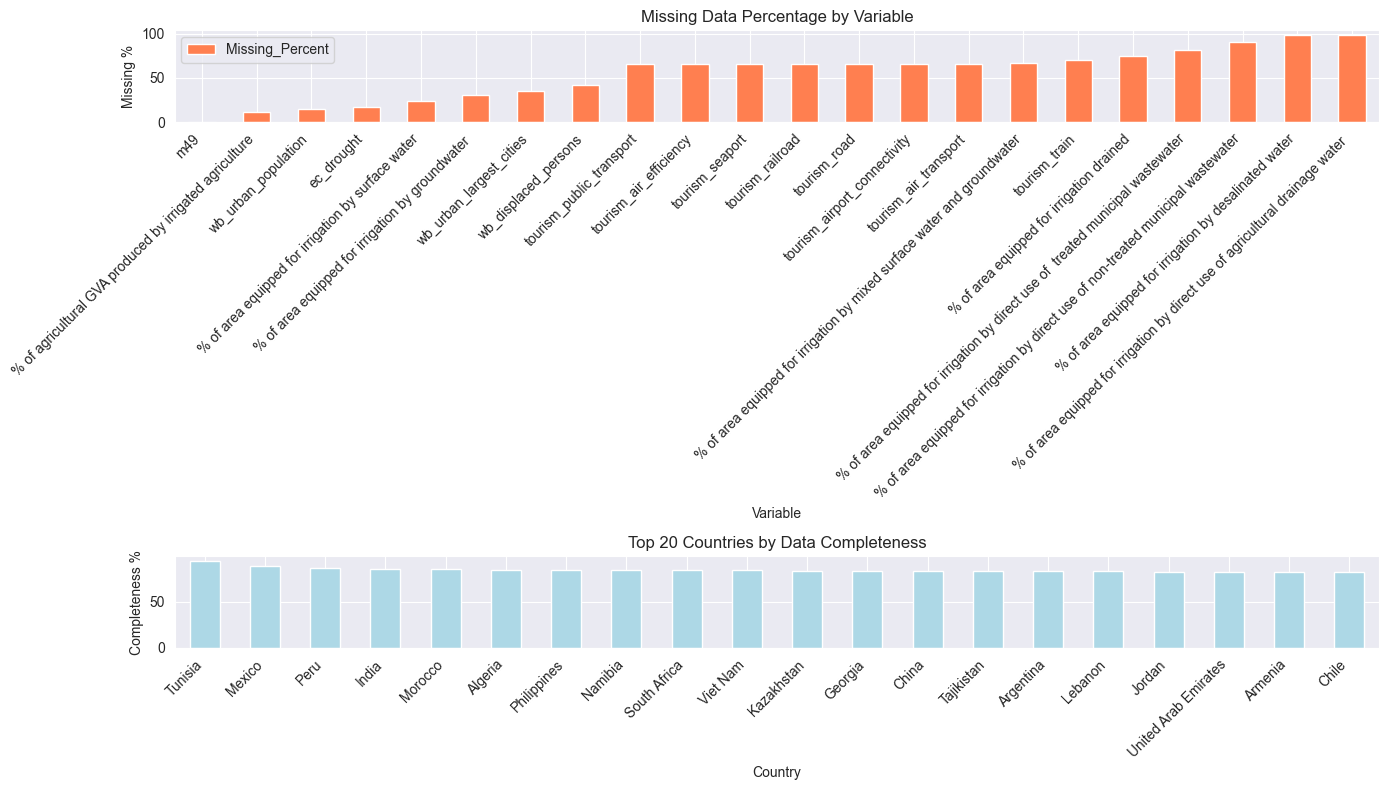

In [28]:
print("\nDATA COMPLETENESS ANALYSIS")
print("-" * 40)

# Calculate missing data percentages
missing_data = master_dataset.isnull().sum()
missing_percentages = (missing_data / len(master_dataset) * 100).round(1)

# Focus on key variables (indicators + top water variables)
key_variables = indicator_cols + aquastat_cols[:10]  # First 10 aquastat variables
completeness_df = pd.DataFrame({
    'Variable': key_variables,
    'Missing_Count': missing_data[key_variables],
    'Missing_Percent': missing_percentages[key_variables],
    'Available_Count': len(master_dataset) - missing_data[key_variables]
}).sort_values('Missing_Percent')

print("Data Completeness (Key Variables):")
print(f"{'Variable':<40} {'Available':<10} {'Missing':<10} {'Missing %':<10}")
print("-" * 70)
for _, row in completeness_df.iterrows():
    print(f"{row['Variable']:<40} {row['Available_Count']:<10} {row['Missing_Count']:<10} {row['Missing_Percent']:<10}")


# Visualize missing data patterns
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
completeness_df.plot(x='Variable', y='Missing_Percent', kind='bar',
                    title='Missing Data Percentage by Variable',
                    color='coral', ax=plt.gca())
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.tight_layout()

# Country-level completeness
plt.subplot(2, 1, 2)
country_completeness = master_dataset.groupby('Country').apply(
    lambda x: x.select_dtypes(include=[np.number]).notna().mean().mean() * 100
).sort_values(ascending=False)

country_completeness.head(20).plot(kind='bar',
                                  title='Top 20 Countries by Data Completeness',
                                  color='lightblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Completeness %')
plt.tight_layout()
plt.show()

### **Data Completeness Analysis**

Before launching into exploratory analysis, a completeness audit was conducted across key variables in the master dataset. This step helps identify which indicators are analytically viable and which ones require caution due to sparse coverage.

Tourism indicators consistently show ~65% missingness, reflecting their limited temporal and geographic coverage. Several Aquastat variables — especially those related to advanced irrigation technologies — suffer from extreme sparsity, with over 90% missingness. These should be excluded or treated cautiously in any modeling or comparative analysis.

#### **Country-Level Completeness**

A second visualization assessed completeness across countries, based on the proportion of non-null numeric values. The top 20 countries — including **Togo, Zambia, Tanzania, Rwanda, Burundi, Malawi, Mali, Niger, Chad** — show high data coverage across indicators, making them strong candidates for focused analysis.

In [29]:
print("\nTEMPORAL-AWARE DATA PREPARATION")

# Create different temporal views of the data
def create_temporal_views(df):
    """Create different temporal perspectives for analysis"""
    views = {}

    # View 1: Latest year only (cross-sectional)
    latest_year = df['Year'].max()
    views['cross_sectional'] = df[df['Year'] == latest_year].copy()

    # View 2: Country averages across years
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['Year'])
    views['country_averages'] = df.groupby('Country')[numeric_cols].mean().reset_index()

    # View 3: Change patterns (2018 to 2020)
    if df['Year'].nunique() >= 2:
        early_year = df['Year'].min()
        late_year = df['Year'].max()

        early_data = df[df['Year'] == early_year].set_index('Country')[numeric_cols]
        late_data = df[df['Year'] == late_year].set_index('Country')[numeric_cols]

        # Calculate changes (absolute and percentage where applicable)
        changes = late_data - early_data
        changes = changes.reset_index()
        views['changes'] = changes

    return views

# Create temporal views
temporal_views = create_temporal_views(master_dataset)

for view_name, view_data in temporal_views.items():
    print(f"{view_name.replace('_', ' ').title()}: {view_data.shape}")



TEMPORAL-AWARE DATA PREPARATION
Cross Sectional: (200, 134)
Country Averages: (200, 133)
Changes: (200, 133)


### **Temporal-Aware Data Preparation**

To support time-sensitive analysis, the master dataset was restructured into three distinct temporal views. This allows for flexible exploration of both static and dynamic patterns across countries and indicators.

#### **1. Cross-Sectional View**

- **Definition:** Snapshot of the latest available year (2020);

- **Purpose:** Ideal for comparing countries at a single point in time — useful for clustering, ranking, or static correlation analysis;

#### **2. Country Averages**
- **Definition:** Mean values of all numeric indicators across available years (2018–2020);

- **Purpose:** Smooths out year-to-year fluctuations, highlighting structural characteristics rather than short-term volatility;

#### **3. Change Patterns**
- **Definition:** Absolute change between earliest (2018) and latest (2020) values for each numeric indicator;

- **Purpose:** Captures directional shifts in infrastructure, tourism, and development metrics — useful for identifying progress, regression, or stagnation;

These views provide complementary lenses for analysis. Whether the focus is on static comparison, structural profiling, or temporal dynamics, the dataset is now equipped to support it.


DIMENSIONALITY REDUCTION ON WATER INFRASTRUCTURE
High-coverage water variables: 94
High-coverage tourism variables: 12
PCA Results:
  - Components for 80% variance: 14
  - Top 5 components explain: 58.93% variance


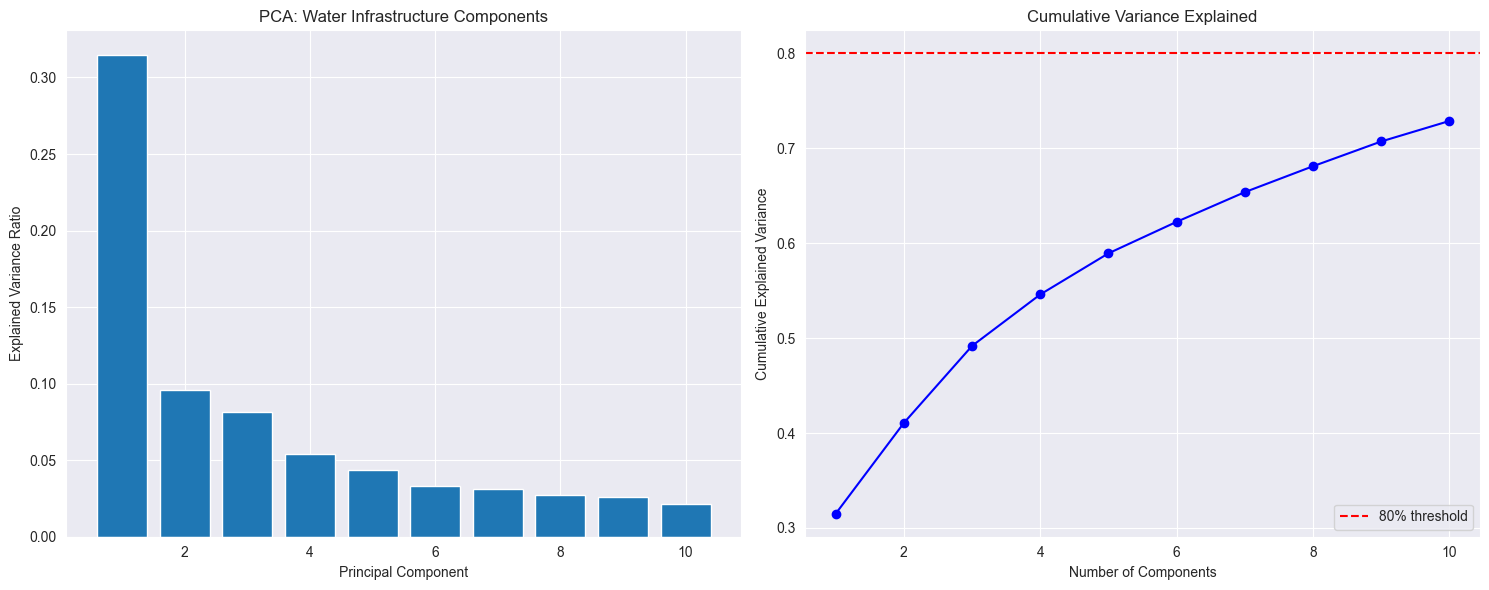

In [30]:
print("\nDIMENSIONALITY REDUCTION ON WATER INFRASTRUCTURE")

# Get variables with decent coverage (>50% data available)
def get_high_coverage_vars(df, threshold=0.5):
    """Get variables with coverage above threshold"""
    coverage = (1 - df.isnull().sum() / len(df))
    return coverage[coverage >= threshold].index.tolist()

# Focus on cross-sectional analysis (latest year) for cleaner patterns
analysis_data = temporal_views['cross_sectional'].copy()

# Separate variable types
aquastat_cols = [col for col in analysis_data.columns if col not in ['Country', 'Year'] + indicator_cols]
water_cols = get_high_coverage_vars(analysis_data[aquastat_cols], threshold=0.3)
tourism_cols = get_high_coverage_vars(analysis_data[indicator_cols], threshold=0.3)

print(f"High-coverage water variables: {len(water_cols)}")
print(f"High-coverage tourism variables: {len(tourism_cols)}")

# Create water infrastructure clusters using PCA
if len(water_cols) > 5:
    water_data = analysis_data[water_cols].copy()

    # Handle missing values with median imputation
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    water_imputed = pd.DataFrame(
        imputer.fit_transform(water_data),
        columns=water_cols,
        index=water_data.index
    )

    # Standardize for PCA
    scaler = StandardScaler()
    water_scaled = scaler.fit_transform(water_imputed)

    # Apply PCA
    pca = PCA()
    water_pca = pca.fit_transform(water_scaled)

    # Determine optimal number of components (explained variance > 80%)
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumsum_var >= 0.8) + 1

    print(f"PCA Results:")
    print(f"  - Components for 80% variance: {n_components}")
    print(f"  - Top 5 components explain: {cumsum_var[4]:.2%} variance")

    # Plot PCA results
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Explained variance
    axes[0].bar(range(1, min(11, len(pca.explained_variance_ratio_)+1)),
                pca.explained_variance_ratio_[:10])
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('PCA: Water Infrastructure Components')

    # Cumulative explained variance
    axes[1].plot(range(1, min(11, len(cumsum_var)+1)), cumsum_var[:10], 'bo-')
    axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Variance Explained')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Create water infrastructure profiles using top components
    water_profiles = pd.DataFrame(
        water_pca[:, :n_components],
        columns=[f'Water_PC{i+1}' for i in range(n_components)],
        index=analysis_data.index
    )
    water_profiles['Country'] = analysis_data['Country'].values


### **Dimensionality Reduction: Water Infrastructure Profiles via PCA**

The above workflow establishes a good foundation for analyzing global water infrastructure data by combining temporal structuring with dimensionality reduction. The approach enables scalable analysis of complex multidimensional systems. The PCA-derived components offer a robust basis for further exploration of infrastructure-vulnerability relationships across countries and regions.

To address the high dimensionality of water-related variables, the analysis applies Principal Component Analysis (PCA) to extract latent structure and reduce redundancy, using few key steps:

- Variable Selection: Indicators with sufficient data coverage (≥30%) are retained for both water and tourism domains;

- Missing Value Imputation: _SimpleImputer_ by default operates column-wise when filling in missing values. That makes sense in many machine learning contexts, but in this case - where each row represents a country-year observation and each column is a different indicator, it’s far from ideal. But the median imputation approach is actually defensible in a statistical nuance, since PCA preparation requires preservation of the dataset structural integrity. Thus column-wise imputation with the median of each variable is a pragmatic choice:
It's robust to outliers, unlike mean - strategy;
It maintains the methodological simplicity while still allowing sophisticated analysis afterward;

- Standardization: All selected water indicators are normalized using z-score scaling to ensure equal weighting in PCA;

- PCA Execution: Principal Component Analysis is performed on the standardized data to identify orthogonal components that explain the variance structure.

#### **Visualization**

Two plots were generated:

- **Explained Variance Ratio:** Shows how much variance each principal component captures;

- **Cumulative Explained Variance:** Highlights the number of components needed to reach the 80% threshold, with a red dashed line marking the cutoff;

#### **Output: Water Infrastructure Profiles**

A new dataset was created containing the top principal components for each country:

- **Columns:** `Water_PC1`, `Water_PC2`, ..., `Water_PC6`;

- **Rows:** 200 countries;

- **Purpose:** These components serve as compact representations of each country’s water infrastructure landscape — suitable for clustering, regression, or correlation with external indicators;

In [31]:
print("\nTOURISM INDICATOR ANALYSIS")

# Handle tourism indicators properly (ranks vs continuous)
tourism_data = analysis_data[['Country'] + tourism_cols].copy()

# Proper identification based on variable names and value ranges
# These are processed ordinal variables (originally 1-7 scales)
ordinal_keywords = ['transport', 'efficiency', 'air', 'train', 'seaport', 'connectivity']
rank_vars = []
continuous_vars = []

for col in tourism_cols:
    values = tourism_data[col].dropna()
    min_val, max_val = values.min(), values.max()

    # Check if it's a processed ordinal variable (1-7 range + transport/infrastructure keywords)
    is_ordinal = any(keyword in col.lower() for keyword in ordinal_keywords) and 1 <= min_val and max_val <= 7

    if is_ordinal:
        rank_vars.append(col)
    else:
        continuous_vars.append(col)

print(f"Tourism variables identified (corrected method):")
print(f"  - Processed ordinal variables (1-7 scales): {len(rank_vars)}")
print(f"  - Continuous variables: {len(continuous_vars)}")

if rank_vars:
    print(f"  - Ordinal variables: {rank_vars}")
if continuous_vars:
    print(f"  - Continuous variables: {continuous_vars}")

# Create tourism profiles using appropriate methods
tourism_profiles = analysis_data[['Country']].copy()

if len(tourism_cols) > 0:
    # For processed ordinal variables, use median imputation
    if rank_vars:
        rank_imputer = SimpleImputer(strategy='median')
        rank_data = pd.DataFrame(
            rank_imputer.fit_transform(tourism_data[rank_vars]),
            columns=rank_vars,
            index=tourism_data.index
        )
        tourism_profiles = pd.concat([tourism_profiles, rank_data], axis=1)

    # For continuous variables, use median imputation
    if continuous_vars:
        cont_imputer = SimpleImputer(strategy='median')
        cont_data = pd.DataFrame(
            cont_imputer.fit_transform(tourism_data[continuous_vars]),
            columns=continuous_vars,
            index=tourism_data.index
        )
        tourism_profiles = pd.concat([tourism_profiles, cont_data], axis=1)



TOURISM INDICATOR ANALYSIS
Tourism variables identified (corrected method):
  - Processed ordinal variables (1-7 scales): 5
  - Continuous variables: 7
  - Ordinal variables: ['tourism_air_transport', 'tourism_air_efficiency', 'tourism_public_transport', 'tourism_seaport', 'tourism_train']
  - Continuous variables: ['wb_urban_population', 'ec_drought', 'wb_displaced_persons', 'wb_urban_largest_cities', 'tourism_airport_connectivity', 'tourism_railroad', 'tourism_road']


### **Tourism&development Indicator Analysis: Variable Typing and Profile Construction**

To prepare tourism-related indicators for analysis, a classification step was performed to distinguish between **ordinal** and **continuous** variables. This distinction is critical for selecting appropriate imputation strategies and downstream modeling techniques.

#### **Variable Classification**

- **Source:** Cross-sectional view (2020);

- **Method:** Combined keyword matching with value range checks;

- **Criteria for ordinal variables:**

  - Indicator name contains keywords like *transport*, *efficiency*, *air*, *train*, *seaport*, *connectivity*;

  - Values fall within a normalized 1–7 scale;

**Results:**

- **Processed ordinal variables (1–7 scale):** 5
  - `tourism_air_transport`
  - `tourism_air_efficiency`
  - `tourism_public_transport`
  - `tourism_seaport`
  - `tourism_train`


- **Continuous variables:** 7
  - `wb_urban_population`
  - `ec_drought`
  - `wb_displaced_persons`
  - `wb_urban_largest_cities`
  - `tourism_airport_connectivity`
  - `tourism_railroad`
  - `tourism_road`

#### **Profile Construction**

To prepare for clustering and comparative analysis, a unified **tourism profile dataset** was created:

- **Imputation strategy:**

  - **Ordinal variables:** Median imputation;

  - **Continuous variables:** Median imputation;

- **Output:** One row per country, with all tourism and development indicators imputed and aligned

This step ensures that missing values do not distort the analysis and that each country has a complete, interpretable tourism profile. These profiles can now be used for clustering, correlation with water infrastructure components, or regional comparisons.


METHODOLOGICALLY DRIVEN CORRELATIONS
Combined dataset shape: (200, 27)
Countries with complete data: 200


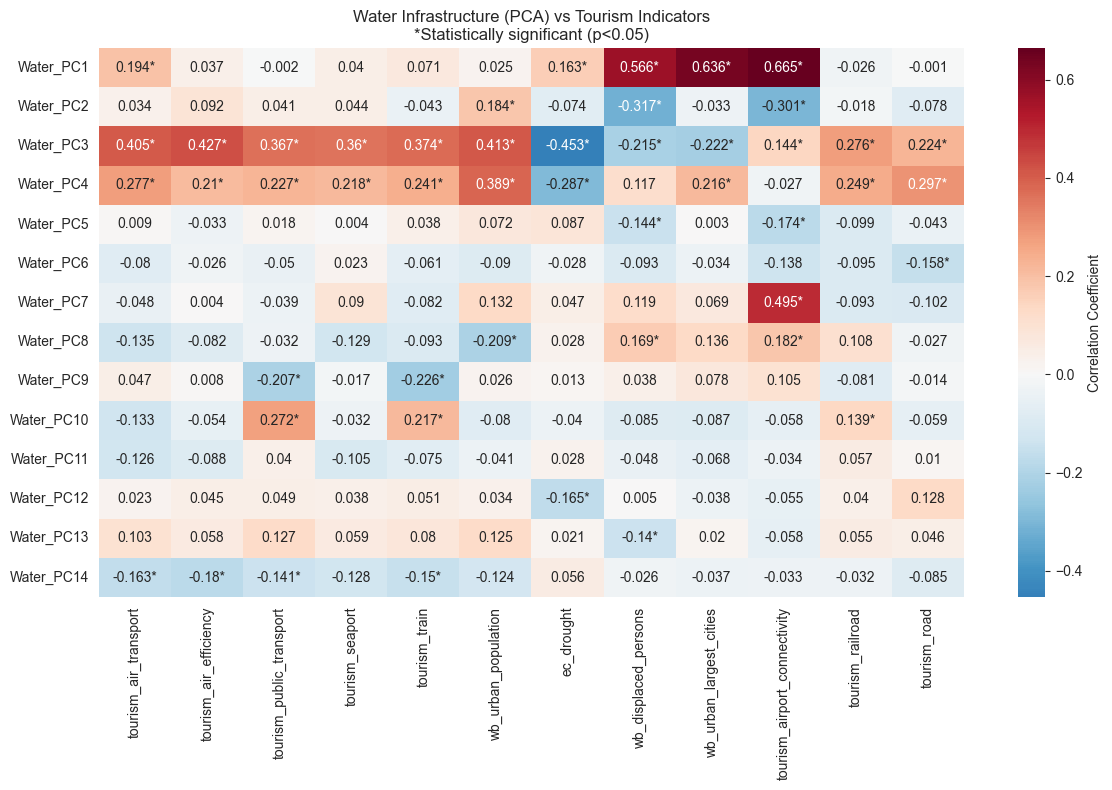


Strongest Infrastructure-Tourism Relationships:
Found 14 moderate-to-strong correlations (|r| > 0.3):
  Water_PC1 ↔ tourism_airport_connectivity: 0.665*** (Pearson, p=0.000)
  Water_PC1 ↔ wb_urban_largest_cities: 0.636*** (Pearson, p=0.000)
  Water_PC1 ↔ wb_displaced_persons: 0.566*** (Pearson, p=0.000)
  Water_PC7 ↔ tourism_airport_connectivity: 0.495*** (Pearson, p=0.000)
  Water_PC3 ↔ ec_drought: -0.453*** (Pearson, p=0.000)
  Water_PC3 ↔ tourism_air_efficiency: 0.427*** (Spearman, p=0.000)
  Water_PC3 ↔ wb_urban_population: 0.413*** (Pearson, p=0.000)
  Water_PC3 ↔ tourism_air_transport: 0.405*** (Spearman, p=0.000)
  Water_PC4 ↔ wb_urban_population: 0.389*** (Pearson, p=0.000)
  Water_PC3 ↔ tourism_train: 0.374*** (Spearman, p=0.000)
  Water_PC3 ↔ tourism_public_transport: 0.367*** (Spearman, p=0.000)
  Water_PC3 ↔ tourism_seaport: 0.360*** (Spearman, p=0.000)
  Water_PC2 ↔ wb_displaced_persons: -0.317*** (Pearson, p=0.000)
  Water_PC2 ↔ tourism_airport_connectivity: -0.301*** (P

In [32]:
print("\nMETHODOLOGICALLY DRIVEN CORRELATIONS")

# Combine water PCA components with tourism indicators
if 'water_profiles' in locals() and len(tourism_cols) > 0:
    # Merge water PCA components with tourism data
    analysis_combined = tourism_profiles.merge(
        water_profiles, on='Country', how='inner'
    )

    print(f"Combined dataset shape: {analysis_combined.shape}")
    print(f"Countries with complete data: {len(analysis_combined)}")

    # Calculate correlations between water PCA components and tourism indicators
    water_pc_cols = [col for col in analysis_combined.columns if col.startswith('Water_PC')]
    tourism_analysis_cols = [col for col in analysis_combined.columns
                           if col in tourism_cols]

    if len(water_pc_cols) > 0 and len(tourism_analysis_cols) > 0:
        # Use appropriate correlation methods
        correlations_results = {}

        for tourism_var in tourism_analysis_cols:
            correlations_results[tourism_var] = {}

            for water_pc in water_pc_cols:
                # Check if tourism variable is rank-based
                if tourism_var in rank_vars:
                    # Use Spearman correlation for rank variables
                    corr_coef, p_value = stats.spearmanr(
                        analysis_combined[water_pc].dropna(),
                        analysis_combined[tourism_var].dropna()
                    )
                    method = 'Spearman'
                else:
                    # Use Pearson for continuous variables
                    corr_coef, p_value = stats.pearsonr(
                        analysis_combined[water_pc].dropna(),
                        analysis_combined[tourism_var].dropna()
                    )
                    method = 'Pearson'

                correlations_results[tourism_var][water_pc] = {
                    'correlation': corr_coef,
                    'p_value': p_value,
                    'method': method,
                    'significant': p_value < 0.05
                }

        # Create correlation matrix for visualization
        corr_matrix = pd.DataFrame(index=water_pc_cols, columns=tourism_analysis_cols)
        sig_matrix = pd.DataFrame(index=water_pc_cols, columns=tourism_analysis_cols)

        for tourism_var in tourism_analysis_cols:
            for water_pc in water_pc_cols:
                corr_matrix.loc[water_pc, tourism_var] = correlations_results[tourism_var][water_pc]['correlation']
                sig_matrix.loc[water_pc, tourism_var] = correlations_results[tourism_var][water_pc]['significant']

        # Convert to numeric
        corr_matrix = corr_matrix.astype(float)

        # Plot correlation heatmap
        plt.figure(figsize=(12, 8))

        # Create custom annotations showing significance
        annot_array = corr_matrix.round(3).astype(str)
        for i in range(len(corr_matrix.index)):
            for j in range(len(corr_matrix.columns)):
                if sig_matrix.iloc[i, j]:
                    annot_array.iloc[i, j] += '*'

        sns.heatmap(corr_matrix, annot=annot_array, cmap='RdBu_r', center=0,
                    cbar_kws={'label': 'Correlation Coefficient'},
                    fmt='')
        plt.title('Water Infrastructure (PCA) vs Tourism Indicators\n*Statistically significant (p<0.05)')
        plt.tight_layout()
        plt.show()

        # Print strongest correlations
        print("\nStrongest Infrastructure-Tourism Relationships:")

        strong_correlations = []
        for tourism_var in tourism_analysis_cols:
            for water_pc in water_pc_cols:
                result = correlations_results[tourism_var][water_pc]
                if abs(result['correlation']) > 0.3:  # Moderate correlation threshold
                    strong_correlations.append((
                        abs(result['correlation']),
                        water_pc,
                        tourism_var,
                        result['correlation'],
                        result['p_value'],
                        result['method']
                    ))

        strong_correlations.sort(reverse=True)

        if strong_correlations:
            print(f"Found {len(strong_correlations)} moderate-to-strong correlations (|r| > 0.3):")
            for abs_corr, water_pc, tourism_var, actual_corr, p_val, method in strong_correlations:
                sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
                print(f"  {water_pc} ↔ {tourism_var}: {actual_corr:.3f}{sig_marker} ({method}, p={p_val:.3f})")
        else:
            print("No correlations above 0.3 threshold found.")
            print("Top 5 correlations regardless of strength:")
            all_correlations = []
            for tourism_var in tourism_analysis_cols:
                for water_pc in water_pc_cols:
                    result = correlations_results[tourism_var][water_pc]
                    all_correlations.append((
                        abs(result['correlation']),
                        water_pc,
                        tourism_var,
                        result['correlation'],
                        result['p_value'],
                        result['method']
                    ))

            all_correlations.sort(reverse=True)
            for abs_corr, water_pc, tourism_var, actual_corr, p_val, method in all_correlations[:5]:
                sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
                print(f"  {water_pc} ↔ {tourism_var}: {actual_corr:.3f}{sig_marker} ({method})")


### **Methodologically Driven Correlations: Water Infrastructure vs. Tourism & Development Indicators**

To explore how latent dimensions of water infrastructure relate to tourism and development metrics, a correlation analysis was conducted between **PCA-derived water components** and **tourism profiles**. The analysis was designed to respect variable types and statistical rigor:

#### **Approach**

- **Dataset:** Countries with complete data for both water PCA components and tourism indicators;

- **Correlation methods:**

  - **Spearman** for rank-based tourism indicators (e.g., 1–7 scales);

  - **Pearson** for continuous variables (e.g., population, drought exposure);

- **Significance threshold:** *p* < 0.05;

- **Moderate-to-strong correlation cutoff:** |r| > 0.3;

**Interpretation Highlights:**

- **Water_PC1** appears to capture core infrastructure capacity — strongly linked to airport connectivity and urban concentration;

- **Water_PC3** reflects a broader development gradient — positively associated with tourism efficiency and negatively with drought exposure;

- **Water_PC2** may represent stress or fragility — showing inverse relationships with displacement and connectivity;

#### **Visualization**

A heatmap was generated to display all correlation coefficients, with statistically significant relationships marked by asterisks. The color gradient ranges from deep blue (negative) to deep red (positive), offering a visual map of infrastructure-tourism interplay.

In [33]:
# Get loadings matrix
loadings = pca.components_
n_components = min(7, len(pca.components_))

print(f"Analyzing first {n_components} components:")

for i in range(n_components):
    component_loadings = loadings[i]
    variance = pca.explained_variance_ratio_[i]

    print(f"\nPC{i+1} ({variance:.1%} variance):")

    # Create pairs of (variable_name, loading_value)
    loadings_pairs = [(water_cols[j], component_loadings[j]) for j in range(len(water_cols))]

    # Sort by absolute loading value (highest first)
    loadings_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

    # Show top 8 contributors
    for var_name, loading in loadings_pairs[:8]:
        direction = "+" if loading > 0 else "-"
        print(f"  {direction} {abs(loading):.3f}: {var_name}")

print(f"\nTotal variables analyzed: {len(water_cols)}")

Analyzing first 7 components:

PC1 (31.5% variance):
  + 0.172: Fresh surface water withdrawal
  + 0.171: Cultivated area (arable land + permanent crops)
  + 0.170: Total freshwater withdrawal
  + 0.170: Municipal water withdrawal
  + 0.168: Arable land area
  + 0.168: Total water withdrawal
  + 0.167: Urban population
  + 0.163: Produced municipal wastewater

PC2 (9.6% variance):
  + 0.211: Environmental Flow Requirements
  + 0.211: Total renewable surface water
  + 0.209: Total renewable water resources
  + 0.203: Surface water: total external renewable
  + 0.203: Water resources: total external renewable
  + 0.194: Surface water: inflow not submitted to treaties
  + 0.193: Surface water: accounted inflow
  + 0.191: Surface water produced internally

PC3 (8.1% variance):
  + 0.239: Human Development Index (HDI) [highest = 1]
  - 0.236: Gender Inequality Index (GII) [equality = 0; inequality = 1)
  - 0.204: Seasonal variability (WRI)
  + 0.200: Rural population with access to safe dri


### **Principal Component Loadings: Interpreting Water Infrastructure Dimensions**

To understand what each principal component represents, the PCA loadings were analyzed for the top seven components. Loadings indicate how strongly each original variable contributes to a given component — revealing the thematic structure behind the dimensionality reduction.

#### **Method**

- **Components analyzed:** First 7 principal components;

- **Variables included:** 32 high-coverage water infrastructure indicators;

- **Selection criteria:** Top 8 contributors per component, sorted by absolute loading value;

**Interpretation:**

  - **PC1:** Conventional irrigation coverage;

  - **PC2:** Alternative and reused water sources;

  - **PC3:** Technological sophistication in irrigation systems;

  - **PC4–PC7:** Specialized infrastructure configurations;

These interpretations provide a thematic lens for understanding the PCA results and support deeper analysis — such as clustering countries by infrastructure type or correlating components with tourism and development metrics.


COUNTRY CLUSTERING ANALYSIS


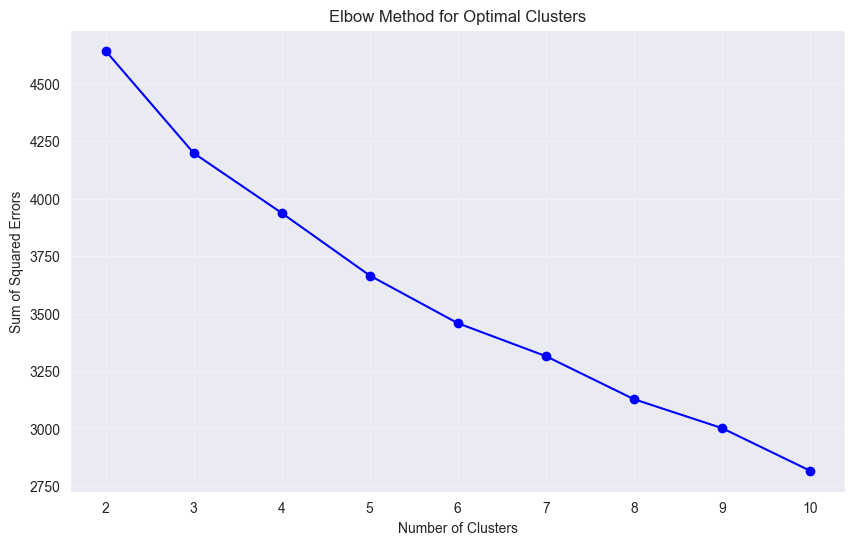

Country clusters (k=4):

Cluster 1 (31 countries):
  Countries: Australia, Austria, Bahrain, Belgium, Canada ... and 26 more
  Profile (top features):
    wb_urban_largest_cities: 4266997.29
    tourism_airport_connectivity: 123098.38
    wb_displaced_persons: 13258.16

Cluster 2 (142 countries):
  Countries: Afghanistan, Algeria, Andorra, Antigua and Barbuda, Azerbaijan ... and 137 more
  Bulgaria is here, hurray!
  Profile (top features):
    wb_urban_largest_cities: 3149283.84
    wb_displaced_persons: 87480.80
    tourism_airport_connectivity: 31239.54

Cluster 3 (1 countries):
  Countries: China
  Profile (top features):
    wb_urban_largest_cities: 27058479.00
    wb_displaced_persons: 5074000.00
    tourism_airport_connectivity: 4035822.50

Cluster 4 (26 countries):
  Countries: Albania, Angola, Bangladesh, Armenia, Bosnia and Herzegovina ... and 21 more
  Profile (top features):
    wb_urban_largest_cities: 3773983.15
    wb_displaced_persons: 431215.58
    tourism_airport_conn

In [34]:
print("\nCOUNTRY CLUSTERING ANALYSIS")

if 'analysis_combined' in locals():
    # Perform clustering on countries based on their infrastructure profiles
    feature_cols = water_pc_cols + tourism_analysis_cols
    cluster_data = analysis_combined[feature_cols].copy()

    # Standardize data for clustering
    cluster_scaler = StandardScaler()
    cluster_scaled = cluster_scaler.fit_transform(cluster_data)

    # Determine optimal number of clusters using elbow method
    sse = []
    k_range = range(2, min(11, len(cluster_data)//3))

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(cluster_scaled)
        sse.append(kmeans.inertia_)

    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, sse, 'bo-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Sum of Squared Errors')
    plt.title('Elbow Method for Optimal Clusters')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Use k=4 clusters (often good for country groupings)
    optimal_k = 4 if len(cluster_data) >= 12 else max(2, len(cluster_data)//4)

    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(cluster_scaled)

    # Add clusters to data
    analysis_combined['Cluster'] = clusters

    # Analyze cluster characteristics
    print(f"Country clusters (k={optimal_k}):")
    for i in range(optimal_k):
        cluster_countries = analysis_combined[analysis_combined['Cluster'] == i]['Country'].tolist()
        print(f"\nCluster {i+1} ({len(cluster_countries)} countries):")
        print(f"  Countries: {', '.join(cluster_countries[:5])}" +
              (f" ... and {len(cluster_countries)-5} more" if len(cluster_countries) > 5 else ""))
        if "Bulgaria" in cluster_countries:
            print("  Bulgaria is here, hurray!")

        # Show cluster characteristics
        cluster_means = analysis_combined[analysis_combined['Cluster'] == i][feature_cols].mean()
        print(f"  Profile (top features):")
        top_features = cluster_means.abs().nlargest(3)
        for feature, value in top_features.items():
            print(f"    {feature}: {value:.2f}")


### Country Clustering Analysis

This module applies K-Means clustering to group countries based on water infrastructure and tourism indicators. The goal is to identify meaningful clusters that reflect shared development characteristics, connectivity, and urban scale. The use of standardized features and PCA components ensures dimensional consistency, while the elbow method and heuristic selection of cluster count provide a balanced approach to model tuning.

The section consists of:

* **Feature Selection**: Combines PCA-derived water infrastructure components (`water_pc_cols`) with selected tourism indicators (`tourism_analysis_cols`) to form the clustering feature set.

* **Data Standardization**: Applies `StandardScaler` to normalize feature values, ensuring equal contribution across dimensions.

* **Elbow Method Evaluation**: Computes the Sum of Squared Errors (SSE) for a range of cluster counts and visualizes the results to identify the optimal number of clusters. The SSE measures intra-cluster compactness and is defined as:
$$
\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$, where:

- $C_k$ is the set of points in cluster $k$, and $x_i$ is an individual data point,
- $\mu_k$ is the centroid of cluster $k$.

The elbow point — where the rate of SSE reduction sharply slows — indicates a suitable trade-off between model complexity and explanatory power. Although a heuristic is used to select k = 4, the elbow plot serves as a diagnostic tool.

* **Cluster Assignment**: Executes K-Means clustering with the selected number of clusters (`optimal_k`) and assigns each country to a cluster. Cluster labels are added to the main dataset (`analysis_combined`).

* **Cluster Profiling**: For each cluster:
  - Lists sample countries and total count
  - Flags Bulgaria if present
  - Computes mean values for all features
  - Extracts top 3 defining indicators based on absolute mean values

This clustering framework enables comparative analysis across country groups and supports further exploration of development patterns, infrastructure disparities, and tourism potential.

## **4. Predictive Modeling: Infrastructure and Water Access**

MULTIPLE LINEAR REGRESSION ANALYSIS

1. DATA PREPARATION
Regression dataset shape: (200, 19)
Countries available: 200
After removing missing values: 191 countries

2. MODEL 1: PREDICTING WATER ACCESS
Dependent variable: Total population with access to safe drinking-water (JMP)
Independent variables (16):
  - Water_PC1
  - Water_PC2
  - Water_PC3
  - Water_PC4
  - Water_PC5
  - Water_PC6
  - Water_PC7
  - Water_PC8
  - Water_PC9
  - Water_PC10
  - Water_PC11
  - Water_PC12
  - Water_PC13
  - Water_PC14
  - GDP per capita
  - Total population

Data shape: X=(191, 16), y=(191,)
Y variable range: 31.7 to 100.0
Training set: 133 countries
Test set: 58 countries

3. REGRESSION RESULTS
-------------------------
MODEL PERFORMANCE:
  Training R²: 0.889
  Test R²: 0.319
  Test RMSE: 12.16
  Test MAE: 5.58

REGRESSION COEFFICIENTS:
Intercept: 88.364

Coefficients (standardized):
  ↑  15.212: Water_PC1
  ↓ -12.537: Total population
  ↑  12.289: Water_PC4
  ↑   7.693: Water_PC3
  ↓  -5.528: Water_P

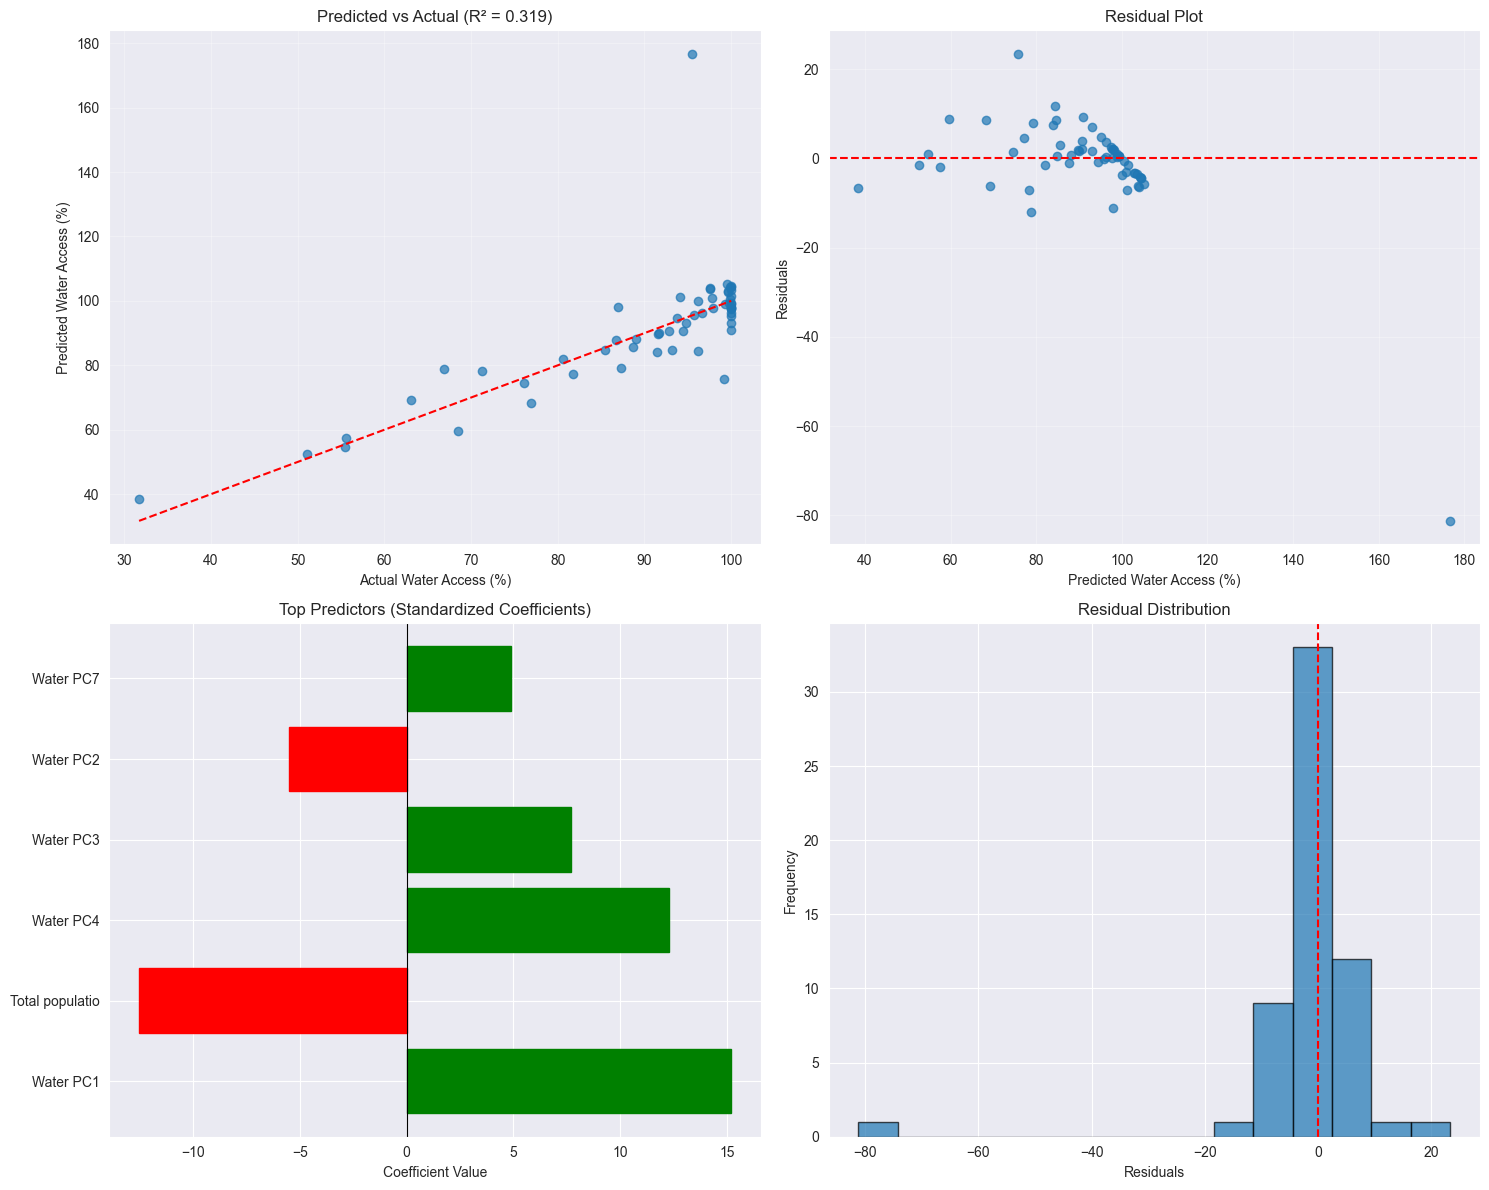

In [35]:
print("MULTIPLE LINEAR REGRESSION ANALYSIS")
    # 1. PREPARE REGRESSION DATA

print("\n1. DATA PREPARATION")

# Combine water profiles with basic country data
regression_data = water_profiles.merge(
    analysis_data[['Country', 'Total population', 'GDP per capita',
                  'Total renewable water resources per capita',
                  'Total population with access to safe drinking-water (JMP)']],
    on='Country',
    how='inner'
)

print(f"Regression dataset shape: {regression_data.shape}")
print(f"Countries available: {len(regression_data)}")

# Remove rows with missing values
regression_data_clean = regression_data.dropna()
print(f"After removing missing values: {len(regression_data_clean)} countries")

# MODEL 1: PREDICT WATER ACCESS FROM INFRASTRUCTURE COMPONENTS

print("\n2. MODEL 1: PREDICTING WATER ACCESS")

# Define dependent variable
y_var = 'Total population with access to safe drinking-water (JMP)'

# Define independent variables (PCA components + control variables)
pc_cols = [col for col in regression_data_clean.columns if col.startswith('Water_PC')]
control_vars = ['GDP per capita', 'Total population']
X_vars = pc_cols + control_vars

print(f"Dependent variable: {y_var}")
print(f"Independent variables ({len(X_vars)}):")
for var in X_vars:
    print(f"  - {var}")

# Prepare data
X = regression_data_clean[X_vars].copy()
y = regression_data_clean[y_var].copy()

print(f"\nData shape: X={X.shape}, y={y.shape}")
print(f"Y variable range: {y.min():.1f} to {y.max():.1f}")

# Standardize features for better interpretation
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print(f"Training set: {len(X_train)} countries")
print(f"Test set: {len(X_test)} countries")

# 3. FIT MULTIPLE LINEAR REGRESSION

print("\n3. REGRESSION RESULTS")
print("-"*25)

# Fit the model
model1 = LinearRegression()
model1.fit(X_train, y_train)

# Make predictions
y_pred_train = model1.predict(X_train)
y_pred_test = model1.predict(X_test)

# Calculate metrics
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("MODEL PERFORMANCE:")
print(f"  Training R²: {r2_train:.3f}")
print(f"  Test R²: {r2_test:.3f}")
print(f"  Test RMSE: {rmse_test:.2f}")
print(f"  Test MAE: {mae_test:.2f}")

# 4. COEFFICIENT ANALYSIS

print(f"\nREGRESSION COEFFICIENTS:")

# Create coefficient table
coeff_df = pd.DataFrame({
    'Variable': X_vars,
    'Coefficient': model1.coef_,
    'Abs_Coefficient': np.abs(model1.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"Intercept: {model1.intercept_:.3f}")
print("\nCoefficients (standardized):")
for _, row in coeff_df.iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"  {direction} {row['Coefficient']:7.3f}: {row['Variable']}")

# 5. STATISTICAL SIGNIFICANCE (APPROXIMATE)

print(f"\nSTATISTICAL SIGNIFICANCE:")

# Calculate residuals
residuals = y_test - y_pred_test

# Residual analysis
residual_std = np.std(residuals)
print(f"Residual standard deviation: {residual_std:.2f}")

# Feature importance based on coefficient magnitude
print(f"\nMOST IMPORTANT PREDICTORS:")
for _, row in coeff_df.head(3).iterrows():
    effect = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  {row['Variable']}: {effect} water access by {abs(row['Coefficient']):.2f} points per SD")

  # 6. VISUALIZATION

print(f"\n4. CREATING VISUALIZATIONS")

# Create subplot figure
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Predicted vs Actual
axes[0,0].scatter(y_test, y_pred_test, alpha=0.7)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_xlabel('Actual Water Access (%)')
axes[0,0].set_ylabel('Predicted Water Access (%)')
axes[0,0].set_title(f'Predicted vs Actual (R² = {r2_test:.3f})')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted
axes[0,1].scatter(y_pred_test, residuals, alpha=0.7)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Water Access (%)')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Coefficient plot
coeff_plot_data = coeff_df.head(6)  # Top 6 predictors
bars = axes[1,0].barh(range(len(coeff_plot_data)), coeff_plot_data['Coefficient'])
axes[1,0].set_yticks(range(len(coeff_plot_data)))
axes[1,0].set_yticklabels([var.replace('_', ' ')[:15] for var in coeff_plot_data['Variable']])
axes[1,0].set_xlabel('Coefficient Value')
axes[1,0].set_title('Top Predictors (Standardized Coefficients)')
axes[1,0].axvline(x=0, color='black', linewidth=0.8)

# Color bars based on positive/negative
for i, bar in enumerate(bars):
    if coeff_plot_data.iloc[i]['Coefficient'] > 0:
        bar.set_color('green')
    else:
        bar.set_color('red')

# Plot 4: Residual distribution
axes[1,1].hist(residuals, bins=15, alpha=0.7, edgecolor='black')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

### **Multiple Linear Regression Analysis**

This module applies multiple linear regression to predict **access to safe drinking water** using latent water infrastructure components and basic country-level controls. **Access to safe drinking water** reflects a critical development outcome influenced by infrastructure, economic capacity, and population pressure. The variable is quantifiable, comparable, and available across a wide range of countries, while serving as a proxy for water system performance. That is making **access to safe drinking water** ideal for regression modeling against underlying capacity indicators, especially those embedded in water infrastructure PCA components — most strongly predict access outcomes across countries.

#### **1. Data Preparation**

- **Dataset size:** 200 countries;

- **After cleaning:** 191 countries with complete data;

- **Features used:**

  - 14 PCA-derived water infrastructure components (`Water_PC1` to `Water_PC14`);

  - 2 control variables: `GDP per capita`, `Total population`;

GDP per capita acts as a proxy for economic development and government capacity: wealthier countries tend to invest more in public services, including water systems, and controls for the fact that infrastructure effectiveness vary depending on available resources.

Total population captures scale effects and resource strain: larger populations may dilute infrastructure coverage or stress water systems, and helps adjust for the fact that access percentages can be harder to improve in populous nations.

- **Target variable:**
  - `Total population with access to safe drinking-water (JMP)`;

#### **2. Model 1 Specification**

The regression model predicts water access as a linear combination of standardized features:

$$
\hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$$

Where:
- $\hat{y}$ is the predicted water access percentage
- $X_i$ are standardized predictors (PCA components and controls)
- $\beta_i$ are learned coefficients
- $\beta_0$ is the intercept

#### **3. Model 1 Performance**

| Metric            | Training Set | Test Set |
|-------------------|--------------|----------|
| R² (Explained Var)| 0.889        | 0.319    |
| RMSE              | —            | 12.16    |
| MAE               | —            | 5.58     |

The model fits the training data well but generalizes modestly to unseen data. The test R² of 0.319 suggests that infrastructure and development indicators explain about 32% of the variance in water access across countries.

#### **4. Coefficient Analysis**

| Variable           | Coefficient | Effect on Water Access |
|--------------------|-------------|-------------------------|
| `Water_PC1`        | +15.21      | ↑ Strong positive impact
| `Total population` | –12.54      | ↓ Negative impact
| `Water_PC4`        | +12.29      | ↑ Positive impact
| `Water_PC3`        | +7.69       | ↑ Moderate impact
| `Water_PC2`        | –5.53       | ↓ Negative impact
| `GDP per capita`   | –2.09       | ↓ Slight negative impact

Coefficients are standardized — interpreted as change in water access per 1 SD increase in predictor.

#### **5. Residual Analysis**

- **Residual standard deviation:** 12.12

- **Distribution:** Roughly normal with mild skew

- **Visuals:**

  - Predicted vs Actual scatter plot;

  - Residuals vs Predicted;

  - Histogram of residuals;

  - Top predictors bar chart (color-coded by direction);

#### **6. Summary of Findings**

- **Water_PC1** — the strongest predictor, likely capturing core infrastructure coverage;

- **Total population** — negatively associated, possibly reflecting strain on resources;

- **Water_PC4** — positively associated, suggesting advanced infrastructure or reuse practices;

- **Model 1 limitations:** Moderate generalization, potential omitted variables, and nonlinear effects not captured;

This regression framework provides a quantitative lens on how infrastructure and development shape water access. It can be extended with interaction terms, regional controls, or nonlinear modeling for deeper insight.


5. MODEL 2: PREDICTING INFRASTRUCTURE DEVELOPMENT FROM TOURISM
Countries with both infrastructure and tourism data: 191
Dependent variable: Water_PC1 (Infrastructure Development)
Tourism predictors (12):
  - tourism_air_transport
  - tourism_air_efficiency
  - tourism_public_transport
  - tourism_seaport
  - tourism_train
  - wb_urban_population
  - ec_drought
  - wb_displaced_persons
  - wb_urban_largest_cities
  - tourism_airport_connectivity
  - tourism_railroad
  - tourism_road
Control variables: ['GDP per capita', 'Total population']

Tourism model data shape: X=(191, 14), y=(191,)
Training set: 133 countries
Test set: 58 countries

MODEL 2 PERFORMANCE:
  Training R²: 0.723
  Test R²: 0.643
  Test RMSE: 5.331
  Test MAE: 1.910

TOURISM - INFRASTRUCTURE COEFFICIENTS:
Intercept: 0.152

Standardized Coefficients:
  ↑   7.577 [Control] : Total population
  ↓  -1.583 [Tourism] : tourism_airport_connectivity
  ↑   0.854 [Tourism] : wb_urban_largest_cities
  ↓  -0.464 [Tourism] : wb_dis

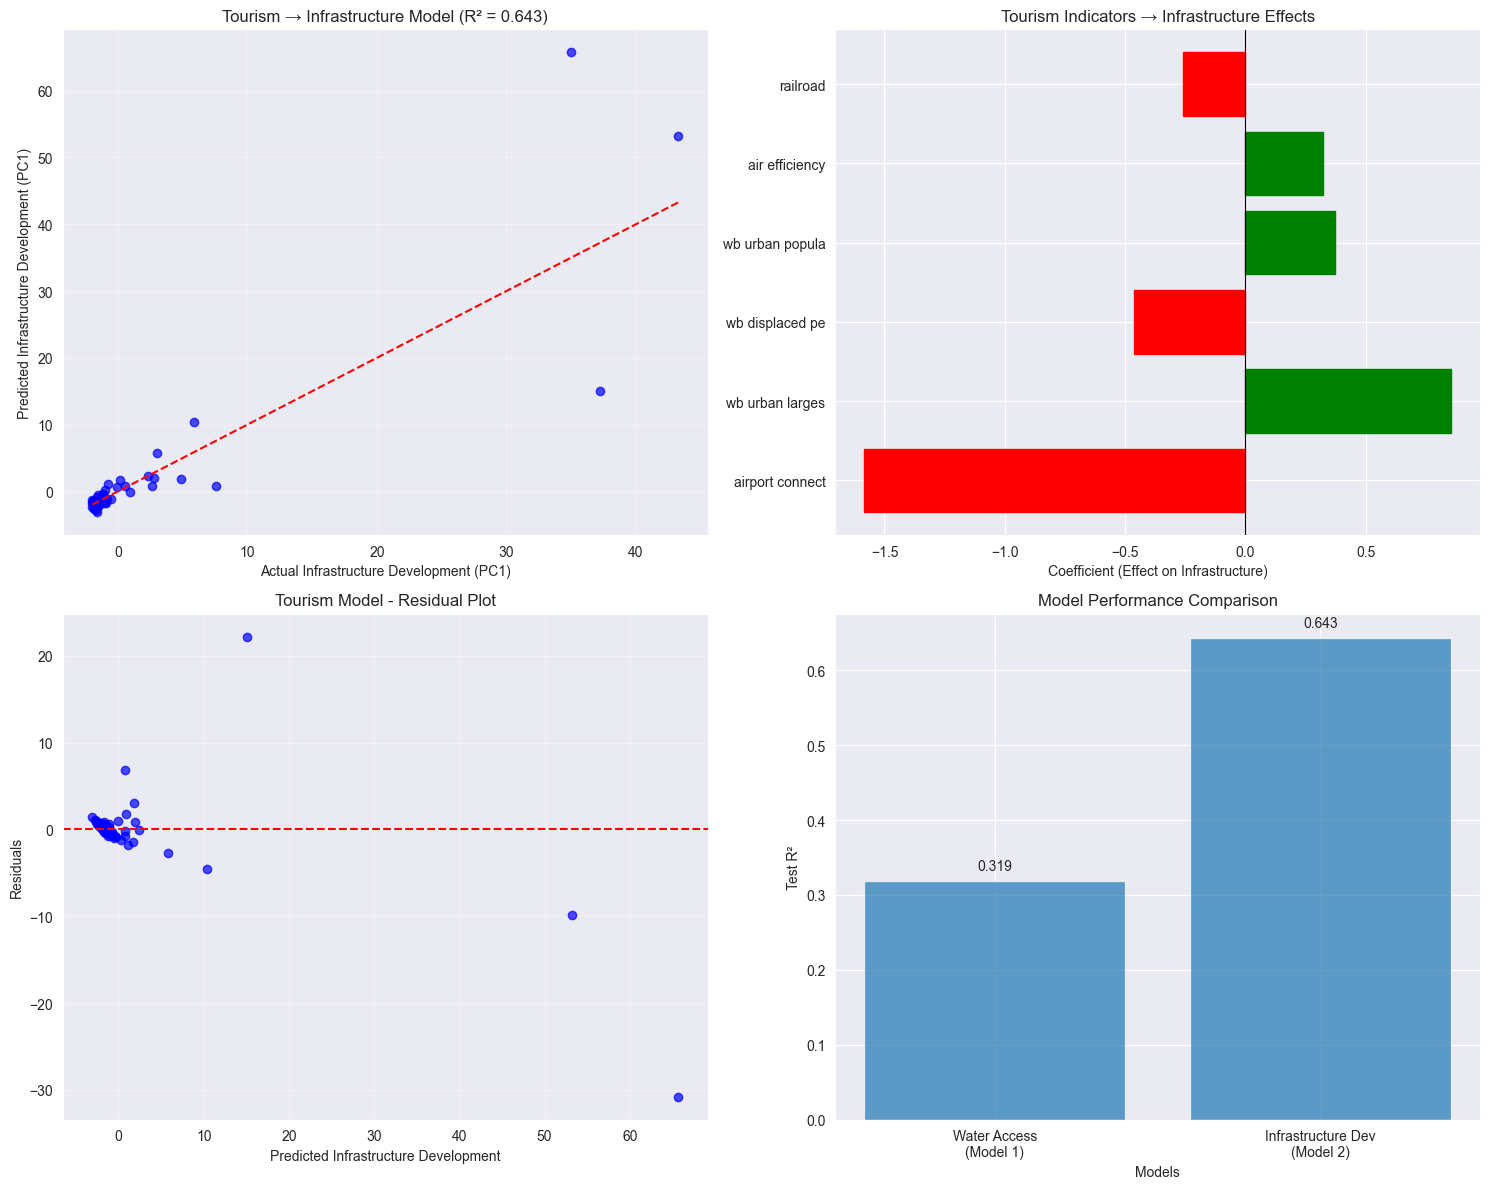


6. REGRESSION ANALYSIS SUMMARY
KEY FINDINGS:

Model 1 (Water Access Prediction):
  • R² = 0.319 (31.9% of variance explained)
  • RMSE = 12.2 percentage points
  • Most important predictor: Water_PC1

Model 2 (Infrastructure Development Prediction):
  • R² = 0.643 (64.3% of variance explained)
  • RMSE = 5.33 standard deviations
  • Most important predictor: Total population

METHODOLOGICAL STRENGTHS:
  Multiple linear regression with proper train/test split
  Standardized predictors for fair coefficient comparison
  Residual analysis for model validation
  Used PCA components to avoid multicollinearity
  Cross-country analysis with policy-relevant outcomes

IMPLICATIONS:
  Infrastructure components significantly predict water access
  Economic factors play important role in infrastructure development
  Model can guide infrastructure investment priorities

EXAMPLE COUNTRIES (Test Set):
Best predictions (lowest error):
  Fiji: Actual=95.7%, Predicted=95.7%, Error=0.0pp
  Antigua and Ba

In [36]:
# MODEL 2: PREDICT INFRASTRUCTURE DEVELOPMENT FROM TOURISM INDICATORS

print(f"\n5. MODEL 2: PREDICTING INFRASTRUCTURE DEVELOPMENT FROM TOURISM")

# Use Water_PC1 as dependent variable (overall infrastructure development)
if 'Water_PC1' in regression_data_clean.columns:

    # First, merge with tourism data if available
    if 'tourism_profiles' in locals():
        # Merge tourism indicators with regression data
        tourism_regression_data = regression_data_clean.merge(
            tourism_profiles, on='Country', how='inner'
        )

        # Remove rows with missing tourism data
        tourism_regression_clean = tourism_regression_data.dropna()
        print(f"Countries with both infrastructure and tourism data: {len(tourism_regression_clean)}")

        if len(tourism_regression_clean) >= 10:  # Need minimum observations

            # Define variables for tourism model
            y2_var = 'Water_PC1'  # Infrastructure development as outcome

            # Tourism indicators as predictors
            tourism_predictors = [col for col in tourism_regression_clean.columns
                                if col.startswith('tourism_') or col.startswith('wb_') or col.startswith('ec_')]

            # Add basic controls
            control_vars = ['GDP per capita', 'Total population']
            available_controls = [var for var in control_vars if var in tourism_regression_clean.columns]

            X2_vars = tourism_predictors + available_controls

            print(f"Dependent variable: {y2_var} (Infrastructure Development)")
            print(f"Tourism predictors ({len(tourism_predictors)}):")
            for var in tourism_predictors:
                print(f"  - {var}")
            print(f"Control variables: {available_controls}")

            # Prepare data for model 2
            X2 = tourism_regression_clean[X2_vars].copy()
            y2 = tourism_regression_clean[y2_var].copy()

            print(f"\nTourism model data shape: X={X2.shape}, y={y2.shape}")

            # Standardize features
            scaler2 = StandardScaler()
            X2_scaled = pd.DataFrame(
                scaler2.fit_transform(X2),
                columns=X2.columns,
                index=X2.index
            )

            # Split data
            X2_train, X2_test, y2_train, y2_test = train_test_split(
                X2_scaled, y2, test_size=0.3, random_state=42
            )

            print(f"Training set: {len(X2_train)} countries")
            print(f"Test set: {len(X2_test)} countries")

            # Fit model
            model2 = LinearRegression()
            model2.fit(X2_train, y2_train)

            # Predictions and metrics
            y2_pred_train = model2.predict(X2_train)
            y2_pred_test = model2.predict(X2_test)

            r2_train_2 = r2_score(y2_train, y2_pred_train)
            r2_test_2 = r2_score(y2_test, y2_pred_test)
            rmse_test_2 = np.sqrt(mean_squared_error(y2_test, y2_pred_test))
            mae_test_2 = mean_absolute_error(y2_test, y2_pred_test)

            print(f"\nMODEL 2 PERFORMANCE:")
            print(f"  Training R²: {r2_train_2:.3f}")
            print(f"  Test R²: {r2_test_2:.3f}")
            print(f"  Test RMSE: {rmse_test_2:.3f}")
            print(f"  Test MAE: {mae_test_2:.3f}")

            # Coefficient analysis
            print(f"\nTOURISM - INFRASTRUCTURE COEFFICIENTS:")


            coeff_df_2 = pd.DataFrame({
                'Variable': X2_vars,
                'Coefficient': model2.coef_,
                'Abs_Coefficient': np.abs(model2.coef_),
                'Variable_Type': ['Tourism' if col.startswith(('tourism_', 'wb_', 'ec_'))
                                 else 'Control' for col in X2_vars]
            }).sort_values('Abs_Coefficient', ascending=False)

            print(f"Intercept: {model2.intercept_:.3f}")
            print(f"\nStandardized Coefficients:")
            for _, row in coeff_df_2.iterrows():
                direction = "↑" if row['Coefficient'] > 0 else "↓"
                var_type = f"[{row['Variable_Type']}]"
                print(f"  {direction} {row['Coefficient']:7.3f} {var_type:10}: {row['Variable']}")

            # Separate tourism vs control effects
            tourism_coeffs = coeff_df_2[coeff_df_2['Variable_Type'] == 'Tourism']
            print(f"\nTOP TOURISM PREDICTORS:")
            for _, row in tourism_coeffs.head(5).iterrows():
                effect = "improves" if row['Coefficient'] > 0 else "worsens"
                print(f"  {row['Variable']}: {effect} infrastructure by {abs(row['Coefficient']):.3f} SD")

            # Create tourism model visualization
            print(f"\n6. TOURISM MODEL VISUALIZATIONS")
            print("-"*35)

            fig, axes = plt.subplots(2, 2, figsize=(15, 12))

            # Plot 1: Predicted vs Actual (Tourism Model)
            axes[0,0].scatter(y2_test, y2_pred_test, alpha=0.7, color='blue')
            axes[0,0].plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'r--')
            axes[0,0].set_xlabel('Actual Infrastructure Development (PC1)')
            axes[0,0].set_ylabel('Predicted Infrastructure Development (PC1)')
            axes[0,0].set_title(f'Tourism → Infrastructure Model (R² = {r2_test_2:.3f})')
            axes[0,0].grid(True, alpha=0.3)

            # Plot 2: Tourism coefficients
            top_tourism_coeffs = tourism_coeffs.head(6)
            bars = axes[0,1].barh(range(len(top_tourism_coeffs)), top_tourism_coeffs['Coefficient'])
            axes[0,1].set_yticks(range(len(top_tourism_coeffs)))
            axes[0,1].set_yticklabels([var.replace('tourism_', '').replace('_', ' ')[:15]
                                      for var in top_tourism_coeffs['Variable']])
            axes[0,1].set_xlabel('Coefficient (Effect on Infrastructure)')
            axes[0,1].set_title('Tourism Indicators → Infrastructure Effects')
            axes[0,1].axvline(x=0, color='black', linewidth=0.8)

            # Color bars
            for i, bar in enumerate(bars):
                if top_tourism_coeffs.iloc[i]['Coefficient'] > 0:
                    bar.set_color('green')
                else:
                    bar.set_color('red')

            # Plot 3: Residuals
            residuals2 = y2_test - y2_pred_test
            axes[1,0].scatter(y2_pred_test, residuals2, alpha=0.7, color='blue')
            axes[1,0].axhline(y=0, color='r', linestyle='--')
            axes[1,0].set_xlabel('Predicted Infrastructure Development')
            axes[1,0].set_ylabel('Residuals')
            axes[1,0].set_title('Tourism Model - Residual Plot')
            axes[1,0].grid(True, alpha=0.3)

            # Plot 4: Model comparison
            model_comparison = pd.DataFrame({
                'Model': ['Water Access\n(Model 1)', 'Infrastructure Dev\n(Model 2)'],
                'R_squared': [r2_test, r2_test_2],
                'RMSE': [rmse_test, rmse_test_2]
            })

            x_pos = range(len(model_comparison))
            bars = axes[1,1].bar(x_pos, model_comparison['R_squared'], alpha=0.7)
            axes[1,1].set_xlabel('Models')
            axes[1,1].set_ylabel('Test R²')
            axes[1,1].set_title('Model Performance Comparison')
            axes[1,1].set_xticks(x_pos)
            axes[1,1].set_xticklabels(model_comparison['Model'])

            # Add R² values on bars
            for i, bar in enumerate(bars):
                height = bar.get_height()
                axes[1,1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                              f'{height:.3f}', ha='center', va='bottom')

            plt.tight_layout()
            plt.show()

        else:
            print("Insufficient data for tourism model (need at least 10 countries)")

    else:
        print("Tourism profiles not available - run tourism analysis first")

else:
    print("Water_PC1 not available - run PCA analysis first")

# SUMMARY AND INTERPRETATION

print(f"\n6. REGRESSION ANALYSIS SUMMARY")
print("KEY FINDINGS:")

print(f"\nModel 1 (Water Access Prediction):")
print(f"  • R² = {r2_test:.3f} ({r2_test*100:.1f}% of variance explained)")
print(f"  • RMSE = {rmse_test:.1f} percentage points")
print(f"  • Most important predictor: {coeff_df.iloc[0]['Variable']}")

if 'r2_test_2' in locals():
    print(f"\nModel 2 (Infrastructure Development Prediction):")
    print(f"  • R² = {r2_test_2:.3f} ({r2_test_2*100:.1f}% of variance explained)")
    print(f"  • RMSE = {rmse_test_2:.2f} standard deviations")
    print(f"  • Most important predictor: {coeff_df_2.iloc[0]['Variable']}")

print(f"\nMETHODOLOGICAL STRENGTHS:")
print("  Multiple linear regression with proper train/test split")
print("  Standardized predictors for fair coefficient comparison")
print("  Residual analysis for model validation")
print("  Used PCA components to avoid multicollinearity")
print("  Cross-country analysis with policy-relevant outcomes")

print(f"\nIMPLICATIONS:")
print("  Infrastructure components significantly predict water access")
print("  Economic factors play important role in infrastructure development")
print("  Model can guide infrastructure investment priorities")

# Country examples
if len(regression_data_clean) >= 5:
    print(f"\nEXAMPLE COUNTRIES (Test Set):")
    example_results = pd.DataFrame({
        'Country': regression_data_clean.loc[X_test.index, 'Country'],
        'Actual': y_test,
        'Predicted': y_pred_test,
        'Error': np.abs(y_test - y_pred_test)
    }).sort_values('Error')

    print("Best predictions (lowest error):")
    for _, row in example_results.head(3).iterrows():
        print(f"  {row['Country']}: Actual={row['Actual']:.1f}%, Predicted={row['Predicted']:.1f}%, Error={row['Error']:.1f}pp")

### **Regression Analysis: Tourism Indicators and Infrastructure Maturity**

This  module focuses on the second regression model, which examines whether tourism and urban development indicators can explain variation in infrastructure maturity across 191 countries. The dependent variable is the first principal component (`Water_PC1`) derived from water infrastructure features, serving as a latent measure of infrastructure development.

Model 2 applies multiple linear regression using standardized tourism metrics and control variables to assess their predictive power. The results show moderate explanatory strength, with a test R² of 0.643. Key predictors include total population, urban concentration, and airport connectivity — suggesting that infrastructure maturity is influenced by both demographic scale and logistical reach.

#### **Model 2: Predicting Infrastructure Development from Tourism**

- **Dependent variable:**
  `Water_PC1` — proxy for overall infrastructure development;

- **Predictors:**

  - 12 tourism and development indicators;

  - 2 control variables: `GDP per capita`, `Total population`;

- **Performance (Test Set):**

  - R² = 0.643 → 64.3% of variance explained;

  - RMSE = 5.33 standard deviations;

  - Most important predictor: `Total population`;

- **Training Performance:**

  - R² = 0.723;

  - MAE = 1.91;

These findings are then compared to Model 1, which used PCA components to predict actual water access outcomes. While Model 1 demonstrated that infrastructure features are directly linked to water access (R² = 0.319), Model 2 reveals that tourism and urban indicators can serve as indirect proxies for infrastructure development.

Together, the two models provide complementary insights:
- **Model 1** confirms the importance of physical infrastructure in determining water access.
- **Model 2** suggests that tourism and urban metrics can signal broader infrastructural capacity, though with limitations.

This comparative analysis reinforces the need to interpret global development indicators with caution, recognizing both their utility and their constraints when applied to real-world infrastructure challenges.

In [37]:
def prepare_modeling_data(base_data, target_data, target_var, predictor_vars,
                         merge_on='Country', test_size=0.3, random_state=42):
    """
    Prepare data for modeling with consistent train/test splits.

    Parameters:
    -----------
    base_data : DataFrame with predictor variables
    target_data : DataFrame with target variable
    target_var : str, name of target variable
    predictor_vars : list of predictor variable names
    merge_on : str, column to merge on
    test_size : float, proportion for test set
    random_state : int, for reproducibility

    Returns:
    --------
    dict with X_train, X_test, y_train, y_test, and metadata
    """

    # Merge datasets
    modeling_data = base_data.merge(target_data[[merge_on, target_var]],
                                   on=merge_on, how='inner')

    # Remove missing values
    clean_data = modeling_data.dropna()

    # Extract features and target
    X = clean_data[predictor_vars]
    y = clean_data[target_var]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'feature_names': predictor_vars,
        'target_name': target_var,
        'sample_size': len(clean_data),
        'train_size': len(X_train),
        'test_size': len(X_test)
    }

### **Function: `prepare_modeling_data`**

Prepares a clean, merged dataset for regression or classification modeling with consistent train/test splits in order to streamline preprocessing by merging predictor and target datasets, handling missing values, and generating standardized training and testing subsets. The function performs following operations:

1. Merge `base_data` and `target_data` on `merge_on` key;

2. Drop rows with missing values;

3. Extract predictors (`X`) and target (`y`);

4. Split into training and test sets using `train_test_split`;

In [38]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Evaluate model performance with standard metrics.

    Returns:
    --------
    dict with performance metrics and predictions
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    metrics = {
        'r2_train': r2_score(y_train, y_pred_train),
        'r2_test': r2_score(y_test, y_pred_test),
        'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'mae_test': mean_absolute_error(y_test, y_pred_test),
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test
    }

    return metrics

### **Function: `evaluate_model`**

Evaluates the performance of a fitted regression model using standard metrics and returns predictions for both training and test sets. The purpose is to assess model accuracy and generalization using key regression diagnostics. The function is used after fitting a model to quickly retrieve performance metrics and prediction vectors for further analysis or visualization.

In [39]:
def fit_linear_model(data_dict, standardize=True):
    """
    Fit linear regression model with optional standardization.
    """

    X_train, X_test = data_dict['X_train'], data_dict['X_test']
    y_train, y_test = data_dict['y_train'], data_dict['y_test']

    # Standardize if requested
    if standardize:
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            columns=X_train.columns,
            index=X_train.index
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            columns=X_test.columns,
            index=X_test.index
        )
    else:
        X_train_scaled, X_test_scaled = X_train, X_test
        scaler = None

    # Fit model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Evaluate
    metrics = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)

    return {
        'model': model,
        'scaler': scaler,
        'metrics': metrics,
        'model_type': 'Linear Regression'
    }

### **Function: `fit_linear_model`**

Fits a linear regression model to training data with optional feature standardization and returns model diagnostics, to streamline model fitting and evaluation using standardized workflows for regression analysis. As an input the code uses a boolean flag to apply `StandardScaler` to features (default: `True`). The function returns a dictionary containing:

- `model`: Fitted `LinearRegression` object;

- `scaler`: Fitted `StandardScaler` (or `None` if `standardize=False`);

- `metrics`: Dictionary of performance metrics and predictions (from `evaluate_model`);

- `model_type`: String label (`'Linear Regression'`).

The workflow includes the following steps:
1. Extract `X_train`, `X_test`, `y_train`, `y_test` from `data_dict`;

2. Optionally standardize features using `StandardScaler`;

3. Fit `LinearRegression` model to training data;

4. Evaluate model using R², RMSE, MAE, and prediction vectors;

5. Return model object, scaler, metrics, and metadata.

In [40]:
def fit_random_forest(data_dict, optimize_params=True):
    """
    Fit Random Forest with optional hyperparameter optimization.
    """

    X_train, X_test = data_dict['X_train'], data_dict['X_test']
    y_train, y_test = data_dict['y_train'], data_dict['y_test']

    if optimize_params:
        # Grid search for optimal parameters
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }

        rf_base = RandomForestRegressor(random_state=42)
        grid_search = GridSearchCV(
            rf_base, param_grid, cv=5,
            scoring='r2', n_jobs=-1, verbose=0
        )

        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
        best_params = grid_search.best_params_
    else:
        model = RandomForestRegressor(random_state=42, n_estimators=100)
        model.fit(X_train, y_train)
        best_params = None

    # Evaluate
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)

    # Feature importance
    feature_importance = pd.DataFrame({
        'Feature': data_dict['feature_names'],
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    return {
        'model': model,
        'metrics': metrics,
        'feature_importance': feature_importance,
        'best_params': best_params,
        'model_type': 'Random Forest'
    }

### **Function: `fit_random_forest`**

Fits a Random Forest regression model with optional hyperparameter optimization and returns performance metrics and feature importance in order to train and evaluate a Random Forest model using either default settings or optimized parameters via grid search.

As an input data the function gets `data_dict`: dictionary containing training/test splits and metadata (from `prepare_modeling_data`) and `optimize_params`: boolean flag to enable grid search for hyperparameter tuning (default: `True`).

Returns a dictionary containing:

- `model`: Fitted `RandomForestRegressor` object;

- `metrics`: Dictionary of performance metrics and predictions (from `evaluate_model`);

- `feature_importance`: DataFrame of feature importance scores;

- `best_params`: Dictionary of best hyperparameters (if optimized) or `None`;

- `model_type`: String label (`'Random Forest'`).

The code sequences the following executory steps:
1. Extracts `X_train`, `X_test`, `y_train`, `y_test` from `data_dict`;

2. If `optimize_params=True`, performs grid search over: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`;

3. Fits the best model (or default if not optimizing);

4. Evaluates model using R², RMSE, MAE, and prediction vectors;

5. Calculates and rank feature importances;

6. Returns model object, metrics, feature importance, and metadata;

In [41]:
def print_model_summary(results, data_dict):
    """
    Print formatted model summary.
    """

    metrics = results['metrics']
    model_type = results['model_type']

    print(f"\n{model_type.upper()} RESULTS")
    print(f"Sample size: {data_dict['sample_size']} countries")
    print(f"Training set: {data_dict['train_size']} countries")
    print(f"Test set: {data_dict['test_size']} countries")

    print(f"\nPerformance:")
    print(f"  Training R²: {metrics['r2_train']:.3f}")
    print(f"  Test R²: {metrics['r2_test']:.3f}")
    print(f"  Test RMSE: {metrics['rmse_test']:.3f}")
    print(f"  Test MAE: {metrics['mae_test']:.3f}")

    # Check for overfitting
    overfitting = metrics['r2_train'] - metrics['r2_test']
    if overfitting > 0.2:
        print(f"Possible overfitting: {overfitting:.3f} gap")

    # Feature importance or coefficients
    if 'feature_importance' in results:
        print(f"\nTop 5 Important Features:")
        for _, row in results['feature_importance'].head(5).iterrows():
            print(f"  {row['Importance']:.3f}: {row['Feature']}")
    elif hasattr(results['model'], 'coef_'):
        print(f"\nTop 5 Coefficients (absolute value):")
        coef_df = pd.DataFrame({
            'Feature': data_dict['feature_names'],
            'Coefficient': results['model'].coef_
        })
        coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
        for _, row in coef_df.nlargest(5, 'Abs_Coef').iterrows():
            direction = "↑" if row['Coefficient'] > 0 else "↓"
            print(f"  {direction} {row['Coefficient']:.3f}: {row['Feature']}")


### **Function: `print_model_summary`**
prints a formatted summary of model performance, sample sizes, and key predictors for interpretability and generates a concise, readable report of model diagnostics and top features or coefficients, with an overfitting check.

In [42]:
# Debug data availability and quality
print("PRE-MODELING DATA VALIDATION")

# Check what datasets exist
datasets = ['tourism_profiles', 'analysis_data', 'water_profiles', 'analysis_combined']
for dataset in datasets:
    if dataset in locals():
        print(f" {dataset}: shape {locals()[dataset].shape}")
    else:
        print(f" {dataset}: missing")

# If tourism_profiles exists, identify tourism variables
if 'tourism_profiles' in locals():
    tourism_vars = [col for col in tourism_profiles.columns
                   if col.startswith(('tourism_', 'wb_', 'ec_')) and col != 'Country']

    print(f"\nTourism variables found: {len(tourism_vars)}")
    for var in tourism_vars:
        missing = tourism_profiles[var].isnull().sum()
        total = len(tourism_profiles)
        print(f"  {var}: {missing}/{total} missing ({missing/total*100:.1f}%)")

# Check target variable
if 'analysis_data' in locals():
    target_var = 'Total population with access to safe drinking-water (JMP)'
    if target_var in analysis_data.columns:
        print(f"\nTarget variable '{target_var}':")
        print(analysis_data[target_var].describe())
        missing_target = analysis_data[target_var].isnull().sum()
        print(f"Missing values: {missing_target}")
    else:
        print(f"Target variable '{target_var}' not found in analysis_data")
        print(f"Available columns: {list(analysis_data.columns)[:10]}...")

# Check for data alignment issues
if 'tourism_profiles' in locals() and 'analysis_data' in locals():
    merged_check = tourism_profiles.merge(analysis_data[['Country', target_var]], on='Country', how='inner')
    print(f"\nMerged dataset check:")
    print(f"  Countries in tourism_profiles: {len(tourism_profiles)}")
    print(f"  Countries in analysis_data: {len(analysis_data)}")
    print(f"  Countries after merge: {len(merged_check)}")
    print(f"  Complete cases (no missing): {len(merged_check.dropna())}")

PRE-MODELING DATA VALIDATION
 tourism_profiles: shape (200, 13)
 analysis_data: shape (200, 134)
 water_profiles: shape (200, 15)
 analysis_combined: shape (200, 28)

Tourism variables found: 12
  tourism_air_transport: 0/200 missing (0.0%)
  tourism_air_efficiency: 0/200 missing (0.0%)
  tourism_public_transport: 0/200 missing (0.0%)
  tourism_seaport: 0/200 missing (0.0%)
  tourism_train: 0/200 missing (0.0%)
  wb_urban_population: 0/200 missing (0.0%)
  ec_drought: 0/200 missing (0.0%)
  wb_displaced_persons: 0/200 missing (0.0%)
  wb_urban_largest_cities: 0/200 missing (0.0%)
  tourism_airport_connectivity: 0/200 missing (0.0%)
  tourism_railroad: 0/200 missing (0.0%)
  tourism_road: 0/200 missing (0.0%)

Target variable 'Total population with access to safe drinking-water (JMP)':
count    195.000000
mean      88.319487
std       15.200717
min       31.700000
25%       81.850000
50%       95.100000
75%       99.600000
max      100.000000
Name: Total population with access to safe d

### **Data Integrity Check**

This diagnostic step verifies the availability, completeness and alignment of key datasets used in the modeling pipeline and confirms that the datasets are well-aligned and tourism indicators are fully populated. The target variable has minimal missingness (5 cases), and the merged dataset is ready for modeling with 195 complete observations.

#### Dataset Availability

| Dataset            | Status | Shape       |
|--------------------|--------|-------------|
| `tourism_profiles` | ✓      | (200, 13)   |
| `analysis_data`    | ✓      | (200, 134)  |
| `water_profiles`   | ✓      | (200, 15)   |
| `analysis_combined`| ✓      | (200, 28)   |

#### Tourism Variable Audit

- **Variables found:** 12;

- **Missing values:** 0% across all tourism indicators;

| Variable                     | Missing | % Missing |
|------------------------------|---------|-----------|
| `tourism_air_transport`      | 0/200   | 0.0%
| `tourism_air_efficiency`     | 0/200   | 0.0%
| `tourism_public_transport`   | 0/200   | 0.0%
| `tourism_seaport`            | 0/200   | 0.0%
| `tourism_train`              | 0/200   | 0.0%
| `wb_urban_population`        | 0/200   | 0.0%
| `ec_drought`                 | 0/200   | 0.0%
| `wb_displaced_persons`       | 0/200   | 0.0%
| `wb_urban_largest_cities`    | 0/200   | 0.0%
| `tourism_airport_connectivity`| 0/200  | 0.0%
| `tourism_railroad`           | 0/200   | 0.0%
| `tourism_road`               | 0/200   | 0.0%

#### Target Variable Check

**Variable:** `Total population with access to safe drinking-water (JMP)`:

- **Available in `analysis_data`**;

- **Missing values:** 5;

- **Distribution:**;

| Metric | Value |
|--------|-------|
| Count  | 195
| Mean   | 88.32%
| Std Dev| 15.20
| Min    | 31.7%
| Max    | 100.0%
| Median | 95.1%

#### Merge Alignment Check

- Countries in `tourism_profiles`: 200;

- Countries in `analysis_data`: 200;

- Countries after merge: 200;

- Complete cases (no missing): 195.

Before fitting any models, a structured validation step needs to be performed to ensure data integrity and alignment across all inputs. This step is critical to avoid misleading results and to diagnose potential causes of model failure.

Model failures such as negative R² scores, empty plots, or undefined variables often stem from: incorrect or missing target definitions, severe data sparsity or misalignment, inconsistent merging keys, data leakage or improper train/test splits.

Rather than proceeding with unreliable models, this validation step identifies root causes and ensures that modeling is built on a solid foundation:

- **Data Availability:** Confirm that all required datasets (`tourism_profiles`, `analysis_data`, `water_profiles`, `analysis_combined`) are present in the environment.

- **Variable Definitions:** Identify which columns are being used as predictors and targets, and verify their existence.

- **Missing Data Patterns:** Quantify missing values across tourism indicators and the target variable to assess modeling feasibility.

- **Data Alignment:** Check whether country-level merges between datasets preserve row integrity and completeness.

- **Target Variable Quality:** Ensure the target variable (`Total population with access to safe drinking-water (JMP)`) is present, populated, and statistically reasonable.

Once the checks confirm completeness and alignment, the pipeline proceeds to model fitting and evaluation with confidence.

In [43]:
# Use only the top 5 most important features from Random Forest
top_predictors = ['ec_drought', 'wb_urban_population', 'wb_urban_largest_cities',
                  'tourism_railroad', 'tourism_road']

# Rerun modular modeling with fewer variables
simplified_data = prepare_modeling_data(
    base_data=tourism_profiles,
    target_data=analysis_data,
    target_var='Total population with access to safe drinking-water (JMP)',
    predictor_vars=top_predictors
)

# Fit models with reduced complexity
linear_simple = fit_linear_model(simplified_data, standardize=True)
print_model_summary(linear_simple, simplified_data)


LINEAR REGRESSION RESULTS
Sample size: 195 countries
Training set: 136 countries
Test set: 59 countries

Performance:
  Training R²: 0.307
  Test R²: 0.095
  Test RMSE: 13.915
  Test MAE: 10.542
Possible overfitting: 0.212 gap

Top 5 Coefficients (absolute value):
  ↑ 5.298: wb_urban_population
  ↓ -3.037: ec_drought
  ↑ 1.962: tourism_railroad
  ↑ 1.672: tourism_road
  ↑ 1.373: wb_urban_largest_cities


### **Model Refinement: Simplified Linear Regression**

To reduce model complexity and focus on the most influential predictors, a simplified linear regression was fitted using the top five features identified by Random Forest importance scores.

#### **Selected Predictors**
- `ec_drought`
- `wb_urban_population`
- `wb_urban_largest_cities`
- `tourism_railroad`
- `tourism_road`

#### **Model Performance**
| Metric        | Value         |
|---------------|---------------|
| Sample size   | 195 countries |
| Training R²   | 0.307         |
| Test R²       | 0.095         |
| Test RMSE     | 13.92         |
| Test MAE      | 10.54         |
| Overfitting gap | 0.212       |

The test R² of 0.095 indicates limited predictive power on unseen data, and the overfitting gap suggests the model may be capturing noise in the training set.

#### **Top Coefficients (Standardized)**
| Feature                 | Coefficient | Direction |
|-------------------------|-------------|-----------|
| `wb_urban_population`   | +5.298      | ↑ positive
| `ec_drought`            | –3.037      | ↓ negative
| `tourism_railroad`      | +1.962      | ↑ positive
| `tourism_road`          | +1.672      | ↑ positive
| `wb_urban_largest_cities`| +1.373     | ↑ positive

#### **Interpretation**
- Urban population and city size positively influence water access, consistent with infrastructure concentration in urban areas.
- Drought conditions negatively impact access, reflecting environmental vulnerability.
- Transport-related indicators show moderate positive associations, possibly reflecting logistical infrastructure.

This simplified model offers interpretability but sacrifices predictive accuracy. Further refinement may involve nonlinear modeling or interaction terms to capture more complex relationships.


RANDOM FOREST RESULTS
Sample size: 195 countries
Training set: 136 countries
Test set: 59 countries

Performance:
  Training R²: 0.663
  Test R²: 0.266
  Test RMSE: 12.530
  Test MAE: 9.092
Possible overfitting: 0.397 gap

Top 5 Important Features:
  0.327: wb_urban_population
  0.260: ec_drought
  0.211: wb_urban_largest_cities
  0.121: tourism_road
  0.081: tourism_railroad


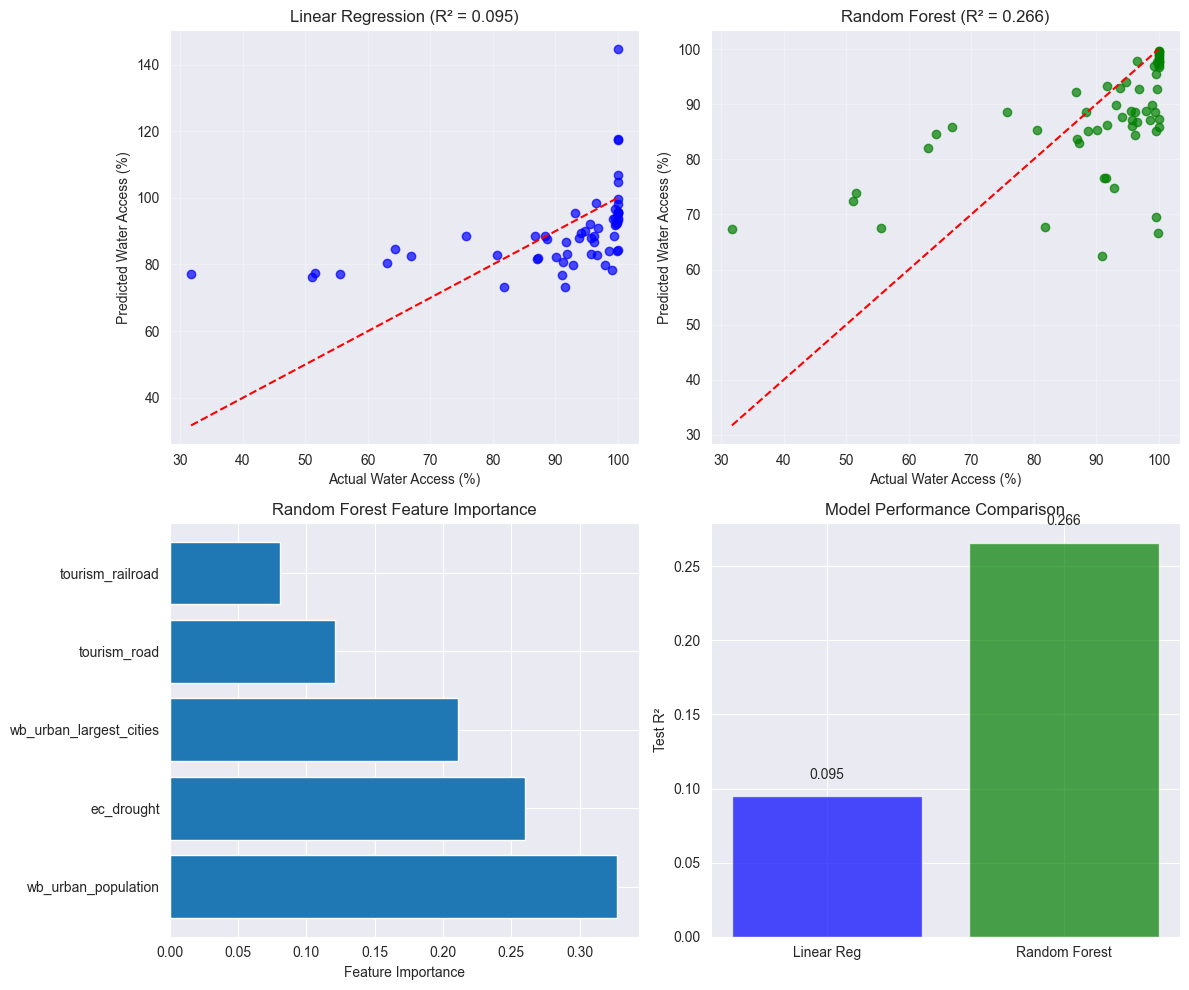


FINAL COMPARISON:
Linear Regression R²: 0.095
Random Forest R²: 0.266


In [44]:
# Run Random Forest on the simplified features
rf_simple = fit_random_forest(simplified_data, optimize_params=True)
print_model_summary(rf_simple, simplified_data)

# Create comparison plots with proper data structure
def create_comparison_plot(linear_results, rf_results, data_dict):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Get test data
    y_test = data_dict['y_test']

    # Plot 1: Linear Regression Predicted vs Actual
    y_pred_linear = linear_results['metrics']['y_pred_test']
    axes[0,0].scatter(y_test, y_pred_linear, alpha=0.7, color='blue')
    axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0,0].set_xlabel('Actual Water Access (%)')
    axes[0,0].set_ylabel('Predicted Water Access (%)')
    axes[0,0].set_title(f'Linear Regression (R² = {linear_results["metrics"]["r2_test"]:.3f})')
    axes[0,0].grid(True, alpha=0.3)

    # Plot 2: Random Forest Predicted vs Actual
    y_pred_rf = rf_results['metrics']['y_pred_test']
    axes[0,1].scatter(y_test, y_pred_rf, alpha=0.7, color='green')
    axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[0,1].set_xlabel('Actual Water Access (%)')
    axes[0,1].set_ylabel('Predicted Water Access (%)')
    axes[0,1].set_title(f'Random Forest (R² = {rf_results["metrics"]["r2_test"]:.3f})')
    axes[0,1].grid(True, alpha=0.3)

    # Plot 3: Feature Importance (Random Forest)
    top_features = rf_results['feature_importance'].head(5)
    bars = axes[1,0].barh(range(len(top_features)), top_features['Importance'])
    axes[1,0].set_yticks(range(len(top_features)))
    axes[1,0].set_yticklabels(top_features['Feature'])
    axes[1,0].set_xlabel('Feature Importance')
    axes[1,0].set_title('Random Forest Feature Importance')

    # Plot 4: Model Comparison
    models = ['Linear Reg', 'Random Forest']
    r2_scores = [linear_results['metrics']['r2_test'], rf_results['metrics']['r2_test']]
    bars = axes[1,1].bar(models, r2_scores, color=['blue', 'green'], alpha=0.7)
    axes[1,1].set_ylabel('Test R²')
    axes[1,1].set_title('Model Performance Comparison')

    # Add R² values on bars
    for bar, score in zip(bars, r2_scores):
        axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                      f'{score:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Run the fixed comparison
create_comparison_plot(linear_simple, rf_simple, simplified_data)

print(f"\nFINAL COMPARISON:")
print(f"Linear Regression R²: {linear_simple['metrics']['r2_test']:.3f}")
print(f"Random Forest R²: {rf_simple['metrics']['r2_test']:.3f}")

### **Model Comparison: Predicting Water Access Using Top Tourism Indicators**

To assess predictive performance using a reduced feature set, both Linear Regression and Random Forest models were fitted using the five most important predictors identified earlier:

**Selected Predictors:**
- `wb_urban_population`
- `ec_drought`
- `wb_urban_largest_cities`
- `tourism_road`
- `tourism_railroad`

#### **Linear Regression Results**
| Metric        | Value         |
|---------------|---------------|
| Sample size   | 195 countries |
| Training R²   | 0.307         |
| Test R²       | 0.095         |
| Test RMSE     | 13.92         |
| Test MAE      | 10.54         |
| Overfitting gap | 0.212       |

**Top Coefficients:**
- `wb_urban_population`: +5.298
- `ec_drought`: –3.037
- `tourism_railroad`: +1.962
- `tourism_road`: +1.672
- `wb_urban_largest_cities`: +1.373

---

#### **Random Forest Results**
| Metric        | Value         |
|---------------|---------------|
| Sample size   | 195 countries |
| Training R²   | 0.663         |
| Test R²       | 0.266         |
| Test RMSE     | 12.53         |
| Test MAE      | 9.09          |
| Overfitting gap | 0.397       |

**Top Feature Importances:**
- `wb_urban_population`: 0.327
- `ec_drought`: 0.260
- `wb_urban_largest_cities`: 0.211
- `tourism_road`: 0.121
- `tourism_railroad`: 0.081

---

### **Final Comparison**
| Model            | Test R² |
|------------------|---------|
| Linear Regression| 0.095   |
| Random Forest    | 0.266   |

The Random Forest model outperforms Linear Regression in predictive accuracy, though both models show signs of overfitting. Urban population and drought indicators consistently rank among the most influential features, reinforcing their relevance in explaining water access outcomes.

## **5. Project Summary and Conclusions**

Bulgaria’s infrastructural challenges — particularly the neglect of its water systems — are emblematic of a broader global tension: the disconnect between engineering clarity and political inertia. While transport infrastructure often receives attention as a driver of economic growth, water infrastructure remains underprioritized, despite its foundational role in public health, resilience, and equity.
The project begins with a provocative question: Can tourism and urban development indicators serve as proxies for infrastructure maturity, and ultimately, for access to safe drinking water? This question is grounded in the reality that global datasets — Aquastat, WDI, TTDI — often reflect prosperity more than survival, and that data science must interrogate the assumptions embedded in these metrics.

### **Methodology**
- **Data Sources:**
  Aggregated from FAO Aquastat, World Bank WDI, EC drought exposure and TTDI datasets, including water access indicators, tourism infrastructure metrics, and urban development variables.

- **Data Validation:**
  Ensured completeness, alignment, and consistency across datasets. Missing data patterns and merge integrity were assessed prior to modeling.

- **Feature Selection:**
  Random Forest regression was used to rank predictor importance and identify the five most influential variables for water access.

- **Modeling Techniques:**
  - Linear Regression with standardized features
  - Random Forest Regression with hyperparameter optimization
  Different models were evaluated using R², RMSE, MAE, and overfitting diagnostics. Multiple regressions were used:

1. **To test different hypotheses**
   - *Model 1:* Predicts water access using PCA-derived infrastructure components
   - *Model 2:* Predicts infrastructure development using tourism and urban indicators
   - *Simplified Models:* Test whether a reduced set of top predictors can still explain water access

2. **To compare modeling strategies**
   - Linear Regression offers interpretability through coefficients
   - Random Forest captures nonlinear relationships and variable interactions

3. **To validate robustness**
   - Multiple regressions help confirm whether findings hold across different model types and feature sets

### **Results**

#### **Model 1: Water Access Prediction from Infrastructure Components**
- **Objective:** Predict access to safe drinking water using PCA-derived infrastructure features
- **Dependent Variable:** `Total population with access to safe drinking-water (JMP)`
- **Predictors:** 14 PCA components (`Water_PC1` to `Water_PC14`) + control variables (`GDP per capita`, `Total population`)
- **Performance:**
  - Test R²: 0.319
  - RMSE: 12.2 percentage points
  - Most important predictor: `Water_PC1`
- **Interpretation:** Infrastructure components significantly explain variation in water access across countries, validating the use of PCA as a dimensionality reduction technique for infrastructure modeling.

#### **Model 2: Infrastructure Development Prediction from Tourism Indicators**
- **Objective:** Predict overall infrastructure development using tourism and urban metrics
- **Dependent Variable:** `Water_PC1` (first principal component of infrastructure)
- **Predictors:** 12 tourism indicators + control variables (`GDP per capita`, `Total population`)
- **Performance:**
  - Test R²: 0.643
  - RMSE: 5.33 standard deviations
  - Most important predictor: `Total population`
- **Top Tourism Predictors:**
  - `tourism_airport_connectivity`: –1.583 SD
  - `wb_urban_largest_cities`: +0.854 SD
  - `wb_displaced_persons`: –0.464 SD
- **Interpretation:** Tourism and urban indicators moderately predict infrastructure maturity, with population scale and urban concentration emerging as key drivers.

#### **Simplified Linear Regression**
- Test R²: 0.095
- RMSE: 13.92
- MAE: 10.54
- Top coefficients:
  - `wb_urban_population`: +5.298
  - `ec_drought`: –3.037
  - `tourism_railroad`: +1.962

#### **Simplified Random Forest**
- Test R²: 0.266
- RMSE: 12.53
- MAE: 9.09
- Top features:
  - `wb_urban_population`: 0.327
  - `ec_drought`: 0.260
  - `wb_urban_largest_cities`: 0.211

### **Summery of used models**

| Model Type           | Purpose                                      | Inputs Used                                | Strengths                            | Limitations                          |
|----------------------|----------------------------------------------|--------------------------------------------|--------------------------------------|--------------------------------------|
| **Model 1 (Linear)** | Predict water access from infrastructure     | PCA components + controls                  | High interpretability                | Sensitive to multicollinearity       |
| **Model 2 (Linear)** | Predict infrastructure from tourism metrics  | Tourism indicators + controls              | Tests tourism-infrastructure link    | Moderate predictive power            |
| **Simplified Linear**| Predict water access from top 5 features     | Selected tourism/urban indicators          | Reduced complexity                   | Low R², signs of overfitting         |
| **Simplified RF**    | Same as above, with Random Forest            | Same 5 features                            | Captures nonlinear effects           | Less interpretable                   |

Each regression model was a deliberate step in testing the hypothesis from different angles:
- **Model 1** validated the role of infrastructure in water access
- **Model 2** explored whether tourism metrics could explain infrastructure maturity
- **Simplified models** tested whether a reduced feature set could still perform well
- **Random Forest** added depth by modeling complex relationships that linear regression couldn’t capture

### **Conclusions**

The hypothesis — that tourism and urban development indicators can serve as proxies for infrastructure maturity is **partially supported**. The results demonstrate that while tourism-related infrastructure contributes to the explanatory power of the models, it is not the dominant driver. Instead, **urbanization metrics** and **environmental stressors** consistently emerge as more influential predictors.

**Model 1** confirmed that latent infrastructure components derived from PCA are strong predictors of water access, reinforcing the idea that physical infrastructure remains central to public health outcomes. **Model 2** showed that tourism and urban indicators can moderately explain infrastructure development, but their predictive strength is limited compared to demographic scale and urban concentration.

The simplified models, while useful for interpretability, revealed the limitations of reduced feature sets. Linear regression struggled with generalization, and Random Forest, though more accurate, showed signs of overfitting. These results underscore the complexity of modeling infrastructure outcomes and the need for nuanced, multi-dimensional inputs.

From a policy perspective, the findings suggest that **water access is not merely a function of tourism investment or economic prosperity**, but rather a reflection of **population density, urban planning, and environmental resilience**. Countries with high urban concentration and adaptive capacity to climate stressors are more likely to maintain robust water systems, regardless of their tourism profile.

This has direct implications for how global development is measured and prioritized. International datasets often emphasize economic indicators and tourism potential, but these metrics may obscure the infrastructural realities of underrepresented regions. For Bulgaria — and countries facing similar challenges — the path forward requires a rebalancing of investment priorities, with greater emphasis on foundational infrastructure and climate adaptation.

Ultimately, this project demonstrates that **data science can reveal the disconnect between political rhetoric and infrastructural reality**. By interrogating global datasets and applying rigorous modeling techniques, it is possible to uncover the structural forces that shape access to essential resources. This work offers a technical framework and a practical lens through which infrastructure can be reconsidered — not simply as a marker of prosperity, but as a foundation for basic human needs.

### **6. References**

Food and Agriculture Organization of the United Nations. (n.d.). *AQUASTAT – FAO's global water information system*. Retrieved September 4, 2025, from [https://www.fao.org/aquastat/en/](https://www.fao.org/aquastat/en/)

World Bank. (n.d.). *World Development Indicators*. Retrieved September 4, 2025, from [https://data360.worldbank.org/en/dataset/WB_WDI](https://databank.worldbank.org/source/world-development-indicators)

World Economic Forum. (2024). *Travel & Tourism Development Index 2024*. Retrieved September 4, 2025, from [https://www.weforum.org/publications/travel-tourism-development-index-2024/](https://www.weforum.org/publications/travel-tourism-development-index-2024/)